<a href="https://colab.research.google.com/github/aridhapebriani/ADW/blob/main/Tugas_Praktikum_ADW_Minggu_2_Kecenderungan_Deret.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Nama: Aridha Pebriani Kusmiran**

## **NIM : M0501251049**



---



# Kecenderungan dalam Deret Waktu

Misalkan suatu deret waktu memiliki fungsi nilaitengah konstan. Model untuk deret waktu tersebut dapat dituliskan sebagai berikut:

$Y_t=\mu_t+X_t$

dengan $E(X_t)=0$ untuk semua $t$.

## Kecenderungan Linear

Deret dikatakan memiliki kecenderungan linear dalam waktu jika $\mu_t$ dapat dinyatakan sebagai:

$\mu_t=\beta_0+\beta_1t$

Berikut simulasi deret yang memiliki kecenderungan linear dalam waktu.

In [182]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import warnings

# Ignore all warnings
warnings.filterwarnings('ignore')

In [183]:
# membangkitkan data waktu dalam bentuk array (misalnya, 100 bulan)
np.random.seed(1049)
n=100
t = np.arange(n)

# Membuat deret dengan kecenderungan linear
beta1 = 0.5 * 49
beta0 = 10 + 49
deret = beta0 + beta1*t

# Menambahkan ingar acak
noise = np.random.normal(scale=2, size=n)  # Noise dengan standar deviasi 2
# jika parameter beta1 dan beta0 menjadi lebih besar, maka noise yang kecil akan menghasilkan plot yang terlalu mulus, jika scale diperbesar maka plot akan lebih menunjukkan pola perubahan antar waktu (lebih realistis)
time_series = deret + noise  # Menggabungkan tren dengan noise

# Membuat DataFrame untuk menyimpan data
df = pd.DataFrame({"Time": pd.date_range(start="2017-01-01", periods=100, freq="M"),
                   "Value": time_series})


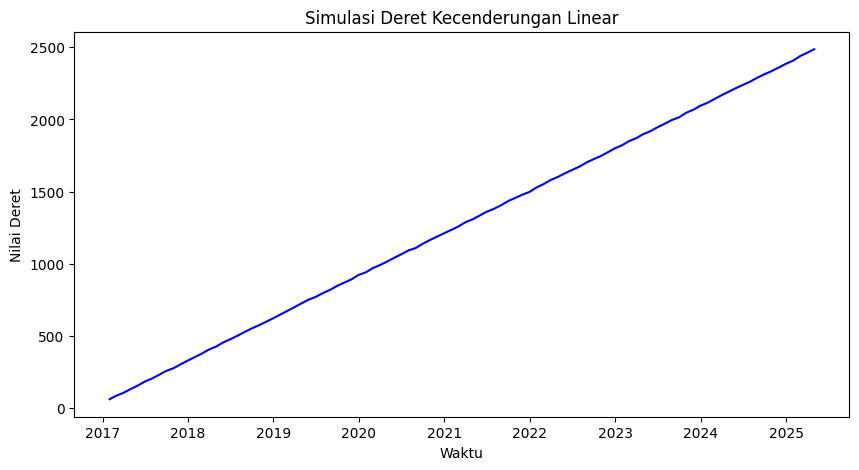

In [184]:
# Plot deret waktu dengan tren linear
plt.figure(figsize=(10, 5))
plt.plot(df["Time"], df["Value"], color="b")
plt.xlabel("Waktu")
plt.ylabel("Nilai Deret")
plt.title("Simulasi Deret Kecenderungan Linear")
plt.show()

**Cek apakah ada korelasi antar pengamatan?**

Berdasarkan grafik deret waktu terlihat adanya kecenderungan linear meningkat. Peningkatan yang sangat kuat terjadi karena nilai parameter kemiringan (β₁) menggunakan penyesuaian berdasarkan dua digit terakhir NIM, yaitu menghasilkan nilai β₁ yang relatif besar dibandingkan variasi noise. Akibatnya, variasi acak menjadi relatif kecil dibandingkan komponen trend.
Selain itu, pada plot deret waktu ini, nilai pengamatan pada suatu periode cenderung memiliki hubungan dengan periode sebelumnya, sehingga terdapat indikasi adanya korelasi positif antar pengamatan. Namun, korelasi tersebut kemungkinan besar dipengaruhi oleh adanya kecenderungan linear (trend) dalam data. Oleh karena itu, diperlukan analisis lanjutan seperti plot ACF atau analisis terhadap residual setelah menghilangkan trend untuk memastikan adanya korelasi selain akibat trend. Untuk memastikan ada atau tidaknya korelasi ini, akan dilakukan visualisasi dengan plot ACF dan uji Durbin-Watson.

## Plot ACF

<Figure size 800x500 with 0 Axes>

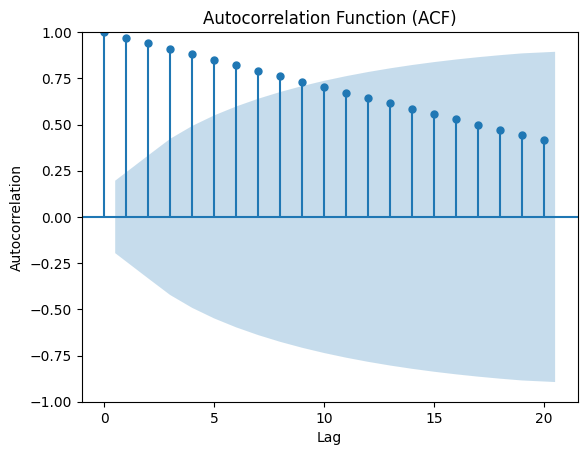

In [185]:
# Plot ACF Data Asli

import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf

plt.figure(figsize=(8,5))

plot_acf(time_series, lags=20)

plt.xlabel("Lag")
plt.ylabel("Autocorrelation")
plt.title("Autocorrelation Function (ACF)")

plt.show()

Berdasarkan plot ACF, terlihat nilai autokorelasi yang sangat tinggi pada lag awal dan menurun secara perlahan seiring bertambahnya lag. Pada lag 1, nilai autokorelasi mendekati 1, yang menunjukkan adanya hubungan positif yang sangat kuat antara pengamatan pada suatu periode dengan periode sebelumnya. Pola ACF yang menurun secara perlahan dan tetap bernilai positif pada banyak lag menunjukkan bahwa deret memiliki kecenderungan linear yang kuat dan belum stasioner. Dengan demikian, dapat disimpulkan bahwa terdapat korelasi positif antar pengamatan, yang terutama dipengaruhi oleh adanya trend linear pada deret waktu.

In [186]:
# Menghilangkan tren linear

import numpy as np
import statsmodels.api as sm

# Membuat indeks waktu
t = np.arange(len(time_series))

# Menambahkan intercept
X = sm.add_constant(t)

# Regresi linear untuk menghilangkan trend
model = sm.OLS(time_series, X).fit()

# Residual
residual = model.resid

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 1.009e+07
Date:                Sat, 05 Sep 2026   Prob (F-statistic):          1.94e-247
Time:                        14:43:05   Log-Likelihood:                -220.94
No. Observations:                 100   AIC:                             445.9
Df Residuals:                      98   BIC:                             451.1
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         59.1824      0.442    133.885      0.0

Setelah dilakukan pemodelan trend linear menggunakan regresi OLS, diperoleh estimasi parameter $(\hat{\beta}_0=59.1824)$ dan $(\hat{\beta}_1=24.5017)$. Nilai tersebut mendekati parameter asli yang digunakan untuk membangkitkan data, yaitu $(\beta_0=59)$ dan $(\beta_1=24.5)$. Nilai Durbin-Watson sebesar 2.170 menunjukkan bahwa residual model tidak mengalami autokorelasi yang signifikan. Hal ini menunjukkan bahwa korelasi pada data asli terutama dipengaruhi oleh adanya komponen trend linear, sedangkan setelah trend dihilangkan residual cenderung bersifat acak.



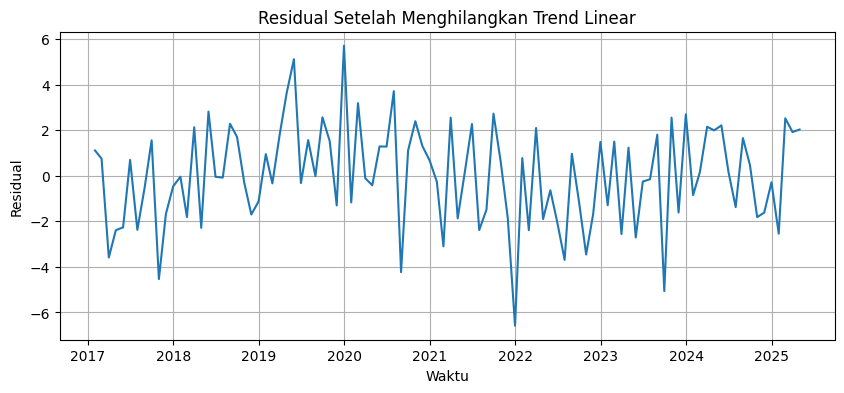

In [187]:
# Plot Residual setelah tren linear dihilangkan

plt.figure(figsize=(10,4))

plt.plot(df["Time"], residual[:len(df["Time"])])

plt.title("Residual Setelah Menghilangkan Trend Linear")
plt.xlabel("Waktu")
plt.ylabel("Residual")

plt.grid()

plt.show()

Berdasarkan plot residual setelah penghilangan trend linear, terlihat bahwa residual berfluktuasi secara acak di sekitar nilai nol tanpa menunjukkan pola tertentu. Hal ini menunjukkan bahwa komponen kecenderungan linear telah berhasil dihilangkan dari data. Residual memiliki variasi yang relatif konstan sepanjang waktu dan tidak menunjukkan adanya pola sistematis, sehingga model trend linear telah mampu menjelaskan sebagian besar pola pada deret waktu.

<Figure size 800x500 with 0 Axes>

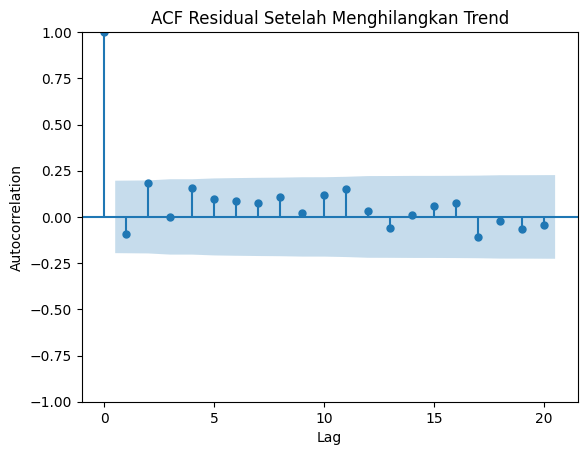

In [188]:
# Plot ACF Residual setelah tren linear dihilangkan

plt.figure(figsize=(8,5))

plot_acf(residual, lags=20)

plt.xlabel("Lag")
plt.ylabel("Autocorrelation")
plt.title("ACF Residual Setelah Menghilangkan Trend")

plt.show()

Berdasarkan plot deret waktu dan ACF data asli, terdapat korelasi positif antar pengamatan yang ditunjukkan oleh nilai autokorelasi tinggi pada beberapa lag. Hal ini terjadi karena adanya kecenderungan linear yang kuat pada data simulasi. Setelah dilakukan penghilangan trend menggunakan regresi linear, residual yang dihasilkan menunjukkan pola acak di sekitar nol dan nilai ACF residual berada dalam batas interval kepercayaan. Dengan demikian, korelasi pada data awal terutama disebabkan oleh keberadaan trend, sedangkan setelah komponen trend dihilangkan residual tidak menunjukkan adanya autokorelasi yang signifikan.

## Uji Durbin Watson

In [189]:
# Uji Durbin Watson setelah tren linear dihilangkan

from statsmodels.stats.stattools import durbin_watson

dw = durbin_watson(residual)

print("Nilai Durbin-Watson:", dw)

Nilai Durbin-Watson: 2.1703757058442705


Berdasarkan hasil uji Durbin-Watson diperoleh nilai sebesar 2.1704. Nilai tersebut mendekati angka 2 yang menunjukkan bahwa residual tidak mengalami autokorelasi. Hasil ini sejalan dengan plot ACF residual yang menunjukkan bahwa nilai autokorelasi pada berbagai lag berada dalam batas interval kepercayaan. Dengan demikian, setelah komponen trend linear dihilangkan, tidak terdapat indikasi korelasi antar pengamatan pada residual.

In [190]:
# Konversi kolom Time menjadi angka (misalnya jumlah bulan sejak periode pertama)
df["Time_Numeric"] = (df["Time"].dt.to_period("M") - df["Time"].dt.to_period("M").min()).apply(lambda x: x.n)

# Hitung korelasi antara Time_Numeric dan Value
correlation = df["Time_Numeric"].corr(df["Value"])

print(f"Nilai korelasi antara Time dan Value: {correlation:.4f}")

Nilai korelasi antara Time dan Value: 1.0000


Berdasarkan hasil perhitungan korelasi Pearson antara waktu dan nilai deret diperoleh nilai korelasi sebesar 1.0000. Hal ini menunjukkan adanya hubungan linear positif yang sangat kuat antara waktu dan nilai deret. Peningkatan waktu selalu diikuti oleh peningkatan nilai deret secara konsisten. Korelasi yang sempurna ini terjadi karena data simulasi dibangkitkan dengan komponen trend linear yang dominan, sehingga perubahan nilai deret hampir seluruhnya dijelaskan oleh faktor waktu.

In [191]:
# Mendefinisikan variabel independen (X) dan dependen (Y)
X = df["Time_Numeric"]
Y = df["Value"]

#memanggil package statsmodels
import statsmodels.api as sm

# Tambahkan konstanta (intercept) ke model regresi
X = sm.add_constant(X)

# Buat dan jalankan model regresi
model = sm.OLS(Y, X).fit()

# menampilkan ringkasan hasil regresi
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  Value   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 1.009e+07
Date:                Sat, 05 Sep 2026   Prob (F-statistic):          1.94e-247
Time:                        14:43:05   Log-Likelihood:                -220.94
No. Observations:                 100   AIC:                             445.9
Df Residuals:                      98   BIC:                             451.1
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const           59.1824      0.442    133.885   

**Bagaimana hasil pengepasan model regresi dibandingkan dengan nilai parameter asli?**

Berdasarkan hasil pengepasan model regresi linear diperoleh estimasi parameter:

$$ \hat{\beta}_0 = 59.1824 $$

dan

$$ \hat{\beta}_1 = 24.5017 $$

Sedangkan parameter asli yang digunakan untuk membangkitkan data adalah:

$$ \beta_0 = 59 $$

dan

$$ \beta_1 = 24.5 $$

Hasil estimasi regresi menunjukkan nilai yang sangat dekat dengan parameter asli. Selisih antara parameter estimasi dan parameter sebenarnya relatif kecil, yaitu sebesar 0.1824 untuk \(\beta_0\) dan 0.0017 untuk \(\beta_1\). Hal ini menunjukkan bahwa model regresi mampu mengestimasi parameter pembangkitan data dengan baik.

**Apakah model regresi yang dipaskan sudah bagus?**

Ya, model regresi linear yang dipaskan dapat dikatakan sudah sangat bagus dalam menggambarkan pola data simulasi. Hal ini terlihat dari nilai koefisien determinasi \($R^2\$) sebesar 1.000 (nilai ditampilkan dengan pembulatan tiga angka desimal). Nilai koefisien determinasi ini menunjukkan bahwa hampir seluruh variasi nilai deret dapat dijelaskan oleh komponen waktu dalam model regresi linear.

Nilai \($R^2\$) yang sangat tinggi ini kemungkinan terjadi karena data simulasi dibangkitkan dengan komponen trend linear yang dominan, yaitu dengan nilai kemiringan:

$$ \beta_1 = 24.5 $$

sedangkan variasi acak yang ditambahkan memiliki standar deviasi yang relatif kecil:

$$ \sigma = 2 $$

sehingga pengaruh noise terhadap pola keseluruhan data menjadi sangat kecil.

Selain itu, hasil estimasi parameter regresi mendekati nilai parameter asli yang digunakan dalam simulasi, serta residual model tidak menunjukkan pola tertentu. Hasil uji Durbin-Watson sebesar 2.170 juga menunjukkan bahwa residual tidak mengalami autokorelasi yang signifikan. Dengan demikian, model regresi linear yang dipaskan sudah mampu menangkap pola trend utama pada data simulasi dengan baik.


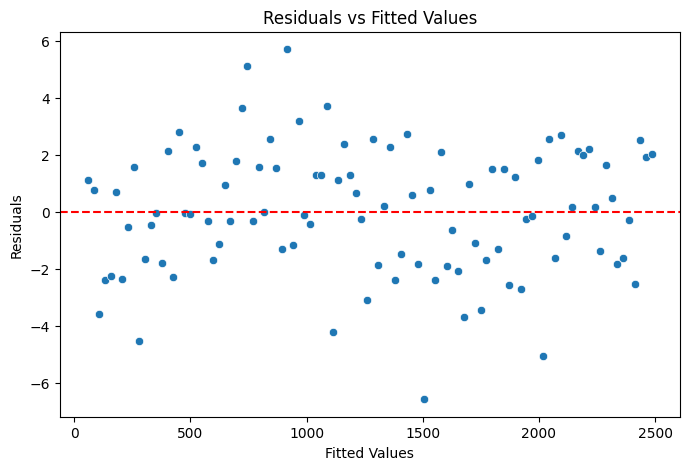

In [192]:
# Analisis Sisaan Model
import seaborn as sns

# Plot Residuals vs. Fitted Values
plt.figure(figsize=(8,5))
sns.scatterplot(x=model.fittedvalues, y=model.resid)
plt.axhline(y=0, color="r", linestyle="--")
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted Values")
plt.show()


**Apa interpretasi dari plot tersebut?**

Berdasarkan plot Residuals vs Fitted Values, residual terlihat menyebar secara acak di sekitar garis nol tanpa membentuk pola tertentu. Hal ini menunjukkan bahwa model regresi linear telah mampu menjelaskan pola utama pada data dengan baik. Selain itu, penyebaran residual yang relatif konstan menunjukkan bahwa tidak terdapat indikasi masalah heteroskedastisitas, sehingga model regresi yang dipaskan dapat dianggap sesuai untuk menggambarkan hubungan antara waktu dan nilai deret.

In [193]:
from statsmodels.stats.diagnostic import het_breuschpagan

# Uji Breusch-Pagan
bp_test = het_breuschpagan(model.resid, model.model.exog)

print(f"P-value Breusch-Pagan Test: {bp_test[1]:.4f}")


P-value Breusch-Pagan Test: 0.8275


**Apa kesimpulan dari nilai uji Breusch Pagan tersebut?**

Berdasarkan hasil uji Breusch-Pagan diperoleh nilai p-value sebesar 0.8275. Karena nilai tersebut lebih besar dari taraf signifikansi 5% (0.05), maka tidak terdapat bukti adanya heteroskedastisitas pada residual model. Dengan demikian, varians residual dapat dianggap konstan (homoskedastisitas), sehingga asumsi kestabilan varians pada model regresi telah terpenuhi.

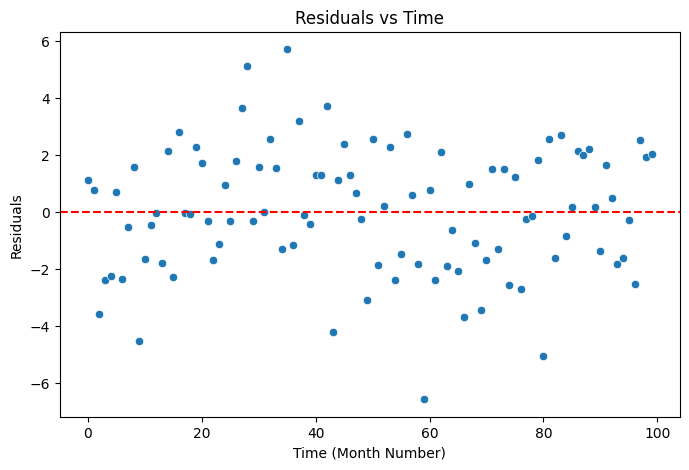

In [194]:
# Plot residual vs time
plt.figure(figsize=(8,5))
sns.scatterplot(x=df["Time_Numeric"], y=model.resid)
plt.axhline(y=0, color="red", linestyle="--")
plt.xlabel("Time (Month Number)")
plt.ylabel("Residuals")
plt.title("Residuals vs Time")
plt.show()


Berdasarkan plot Residuals vs Time, residual model terlihat menyebar secara acak di sekitar nilai nol sepanjang periode pengamatan. Tidak ditemukan adanya pola tertentu atau kecenderungan sistematis terhadap waktu. Hal ini menunjukkan bahwa komponen tren linear telah berhasil dihilangkan dan residual dapat dianggap bersifat acak. Selain itu, penyebaran residual yang relatif konstan menunjukkan bahwa asumsi kestabilan varians residual telah terpenuhi.

<Figure size 800x500 with 0 Axes>

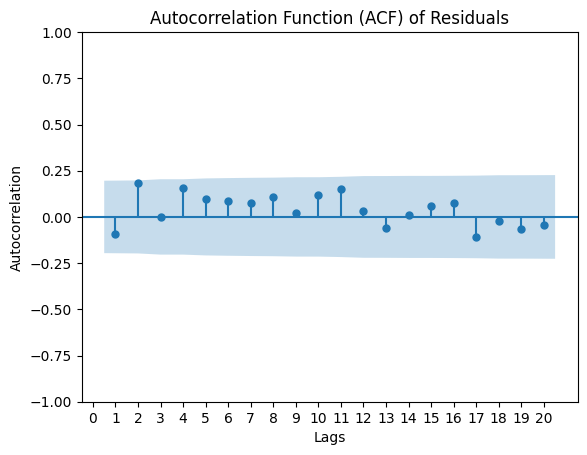

In [195]:
from statsmodels.graphics.tsaplots import plot_acf

# Plot Autocorrelation Function (ACF)
plt.figure(figsize=(8, 5))
plot_acf(model.resid, lags=20, zero=False)
plt.xticks(ticks=range(0, 21, 1))
plt.title("Autocorrelation Function (ACF) of Residuals")
plt.xlabel("Lags")
plt.ylabel("Autocorrelation")
plt.show()


**Apa yang dapat Anda simpulkan dari plot di atas?**

Berdasarkan plot ACF residual, terlihat bahwa nilai autokorelasi pada seluruh lag (lag 1 hingga lag 20) berada di dalam batas interval kepercayaan. Hal ini menunjukkan bahwa tidak terdapat bukti adanya hubungan yang signifikan antara residual pada suatu periode dengan residual pada periode sebelumnya. Nilai ACF residual yang berfluktuasi di sekitar nol mengindikasikan bahwa residual tidak memiliki pola tertentu, baik berupa kecenderungan meningkat, menurun, maupun pola periodik.

Dengan demikian, residual model dapat dianggap mendekati sifat white noise, yaitu memiliki rata-rata mendekati nol, varians yang relatif konstan, serta tidak memiliki ketergantungan antar waktu. Hasil ini menunjukkan bahwa komponen trend linear pada data telah berhasil dijelaskan oleh model regresi, sehingga informasi utama dalam deret waktu sudah berhasil ditangkap oleh model dan tidak ada struktur waktu yang tersisa pada residual. Oleh karena itu, asumsi independensi residual pada model regresi linear telah terpenuhi.

Hasil ini juga konsisten dengan nilai Durbin-Watson sebesar 2.170 yang menunjukkan tidak adanya autokorelasi yang signifikan pada residual. Dengan terpenuhinya asumsi independensi residual, model regresi linear dapat dianggap sesuai untuk menggambarkan hubungan antara waktu dan nilai deret pada data simulasi.

In [196]:
from statsmodels.stats.diagnostic import acorr_ljungbox

# Uji Ljung-Box untuk autokorelasi residual
ljung_box_test = acorr_ljungbox(model.resid, lags=range(1,20), return_df=True)

print("Ljung-Box Test p-value:")
print(ljung_box_test)


Ljung-Box Test p-value:
      lb_stat  lb_pvalue
1    0.847538   0.357250
2    4.307783   0.116032
3    4.307997   0.230069
4    6.834582   0.144892
5    7.897358   0.161984
6    8.741979   0.188617
7    9.334547   0.229521
8   10.599993   0.225410
9   10.652803   0.300260
10  12.233228   0.269751
11  14.788773   0.192373
12  14.915494   0.246090
13  15.372297   0.284691
14  15.390083   0.352020
15  15.779932   0.396826
16  16.430076   0.423369
17  17.938218   0.392749
18  18.013551   0.454760
19  18.548252   0.486140


**Apa kesimpulan dari hasil uji Ljung-Box tersebut?**

Berdasarkan hasil uji Ljung-Box, seluruh nilai p-value pada berbagai lag berada di atas taraf signifikansi 5%. Hal ini menunjukkan bahwa tidak terdapat bukti adanya autokorelasi pada residual model. Dengan kata lain, residual antar periode tidak saling berkorelasi dan dapat dianggap bersifat acak (white noise). Hasil ini menunjukkan bahwa model regresi linear telah berhasil menangkap pola utama pada data, sehingga tidak terdapat struktur waktu yang tersisa pada residual.

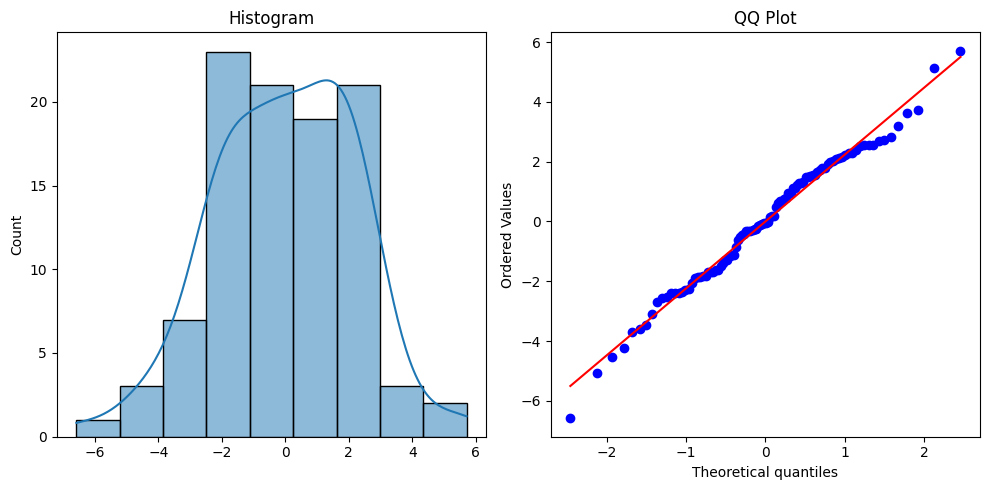

In [197]:
# Histogram Residuals
import scipy.stats as stats
fig, axes = plt.subplots(1, 2, figsize=(10,5))
# Histogram
sns.histplot(model.resid, kde=True, ax=axes[0])
axes[0].set_title('Histogram')

# QQ Plot
stats.probplot(model.resid, dist="norm", plot=axes[1])
axes[1].set_title('QQ Plot')

plt.tight_layout()
plt.show()

**Apa kesimpulan Anda berdasarkan plot di atas?**

Pada histogram residual, terlihat bahwa nilai residual memiliki pola penyebaran yang menyerupai bentuk lonceng (bell-shaped curve), dengan sebagian besar residual terkonsentrasi di sekitar nilai tengah (nilai nol). Frekuensi residual semakin berkurang ketika nilai residual semakin jauh dari pusat distribusi, baik pada sisi positif maupun negatif. Hal ini menunjukkan bahwa kesalahan prediksi model tersebar secara relatif simetris dan tidak mengalami kecenderungan bias ke salah satu arah tertentu.

Selain itu, residual memiliki rentang nilai sekitar \(-6\) hingga \(6\), dengan sebagian besar pengamatan berada pada rentang yang lebih sempit di sekitar nol. Kondisi ini menunjukkan bahwa sebagian besar prediksi model memiliki selisih yang relatif kecil terhadap nilai aktual, sehingga model mampu menjelaskan pola data dengan baik.

Pada QQ Plot, terlihat bahwa sebagian besar titik pengamatan berada di sepanjang garis diagonal merah. Kondisi ini menunjukkan bahwa kuantil residual empiris memiliki kesesuaian yang baik dengan kuantil teoritis dari distribusi normal. Dengan kata lain, distribusi residual yang dihasilkan model memiliki karakteristik yang mendekati distribusi normal.

Terdapat sedikit penyimpangan titik pada bagian ujung (tail) distribusi, terutama pada residual dengan nilai ekstrem. Penyimpangan tersebut menunjukkan adanya beberapa nilai residual yang sedikit berbeda dari pola normal teoritis, tetapi penyimpangan masih relatif kecil dan tidak membentuk pola sistematis. Oleh karena itu, penyimpangan tersebut masih dapat dianggap wajar dan tidak menunjukkan adanya pelanggaran serius terhadap asumsi normalitas residual.

In [198]:
# Uji Shapiro-Wilk
shapiro_stat, shapiro_p_value = stats.shapiro(model.resid)
print(f"Shapiro-Wilk Test: Statistics = {shapiro_stat}, p-value = {shapiro_p_value}")

Shapiro-Wilk Test: Statistics = 0.9882110421024372, p-value = 0.5238963102390225


**Apakah kesimpulan Anda dari nilai uji Shapiro Wilk sama dengan kesimpulan Anda berdasarkan plot?**

Hasil uji Shapiro-Wilk menunjukkan bahwa residual model memiliki nilai statistik 0.9882 dengan p-value sebesar 0.5239. Karena p-value lebih besar dari 0.05, maka asumsi normalitas residual tidak dilanggar. Hasil ini sesuai dengan pemeriksaan visual menggunakan histogram dan QQ Plot, yang menunjukkan bahwa residual menyebar mendekati distribusi normal dengan sebagian besar titik mengikuti garis diagonal. Dengan demikian, residual model regresi dapat dianggap berdistribusi normal.

## Kecenderungan Kuadratik

Deret dikatakan memiliki kecenderungan kuadratik dalam waktu jika $\mu_t$ dapat dinyatakan sebagai:

$\mu_t=\beta_0+\beta_1t+\beta_2t^2$


In [199]:
# Menentukan parameter simulasi
np.random.seed(1049)
n_periods = 120
beta_0, beta_1, beta_2= 50 + 49, 0.5 * 49, 0.02 * 49
noise = np.random.normal(0, 10, n_periods)
time = np.arange(n_periods)

# Membuat komponen kuadratik
quadratic_component = beta_0 + beta_1 * time + beta_2 * time**2

# Menambahkan noise untuk membuat data lebih realistis
data = quadratic_component + noise

# Membuat DataFrame
dates = pd.date_range(start='2010-01-01', periods=n_periods, freq='M')
df_quad = pd.DataFrame({'Date': dates, 'Value': data})

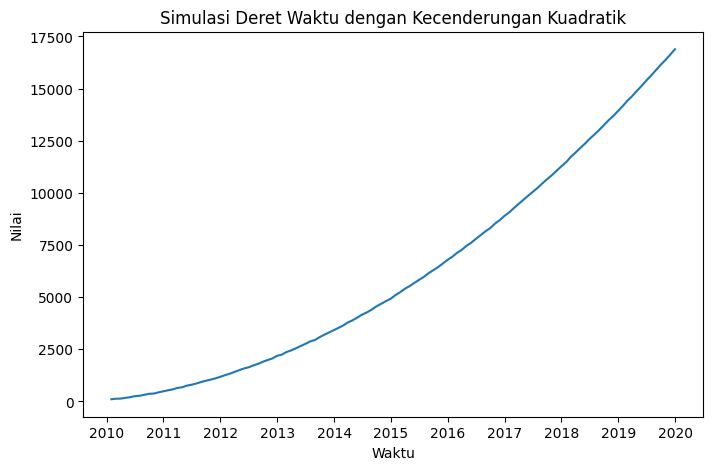

In [200]:
# Plot hasil simulasi deret waktu dengan kecenderungan kuadratik
plt.figure(figsize=(8, 5))
plt.plot(df_quad.Date, df_quad['Value'])
plt.title('Simulasi Deret Waktu dengan Kecenderungan Kuadratik')
plt.xlabel('Waktu')
plt.ylabel('Nilai')
plt.show()

**Apa interpretasi Anda terhadap deret?**

Berdasarkan plot deret waktu dengan kecenderungan kuadratik, terlihat bahwa nilai deret mengalami peningkatan yang semakin cepat seiring bertambahnya waktu. Pada awal periode, kenaikan nilai masih relatif kecil, tetapi setelah beberapa periode nilai deret mulai meningkat secara tajam.

Pola ini menunjukkan adanya kecenderungan kuadratik, di mana perubahan nilai deret tidak hanya dipengaruhi oleh waktu secara linear, tetapi juga oleh komponen kuadrat dari waktu $(t^2)$. Akibat adanya komponen tersebut, laju pertumbuhan deret semakin besar pada periode berikutnya sehingga membentuk pola kurva yang semakin menanjak.

Secara umum, deret menunjukkan adanya pertumbuhan yang mengalami percepatan, bukan hanya peningkatan dengan laju yang konstan.


Apa perbedaan pola yang terlihat dalam deret dibandingkan plot deret pada pola kecenderungan linear? **bold text**

Perbedaan utama terletak pada bentuk pola dan laju perubahan nilai deret. Pada kecenderungan linear, deret membentuk pola garis lurus yang meningkat dengan kemiringan yang relatif tetap. Artinya, peningkatan nilai antarperiode memiliki besar perubahan yang hampir sama.

Sedangkan pada kecenderungan kuadratik, deret membentuk pola kurva melengkung ke atas. Nilai deret tidak hanya meningkat, tetapi peningkatannya semakin besar seiring waktu. Hal ini terjadi karena adanya komponen \(t^2\) yang menyebabkan kemiringan deret berubah dan semakin meningkat.

In [201]:
# Mendefinisikan variabel independen (X) dan dependen (Y)
X = np.column_stack((time, time**2))
X = sm.add_constant(X)
Y = data


# Buat dan jalankan model regresi
model_quad = sm.OLS(Y, X).fit()

# menampilkan ringkasan hasil regresi
print(model_quad.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 1.298e+07
Date:                Sat, 05 Sep 2026   Prob (F-statistic):          1.78e-313
Time:                        14:43:07   Log-Likelihood:                -453.72
No. Observations:                 120   AIC:                             913.4
Df Residuals:                     117   BIC:                             921.8
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         98.2173      2.895     33.925      0.0

Hasil regresi kuadratik menunjukkan bahwa model mampu menangkap pola kecenderungan kuadratik pada data simulasi dengan baik. Estimasi parameter yang diperoleh, yaitu ($\hat{\beta}_0$=98.2173\), ($\hat{\beta}_1$=24.6163\), dan ($\hat{\beta}_2$=0.9789\), sangat mendekati parameter asli yang digunakan dalam pembangkitan datayaitu $(\beta_0=99)$,$(\beta_1=24.5)$, dan $(\beta_2=0.98)$. Selain itu, seluruh koefisien model signifikan secara statistik dan nilai $(R^2=1.000)$ menunjukkan bahwa model mampu menjelaskan hampir seluruh variasi data. Nilai Durbin-Watson sebesar 2.140 juga menunjukkan bahwa residual tidak mengalami autokorelasi yang signifikan. Dengan demikian, model regresi kuadratik sudah sesuai untuk menggambarkan pola kecenderungan pada deret waktu tersebut.

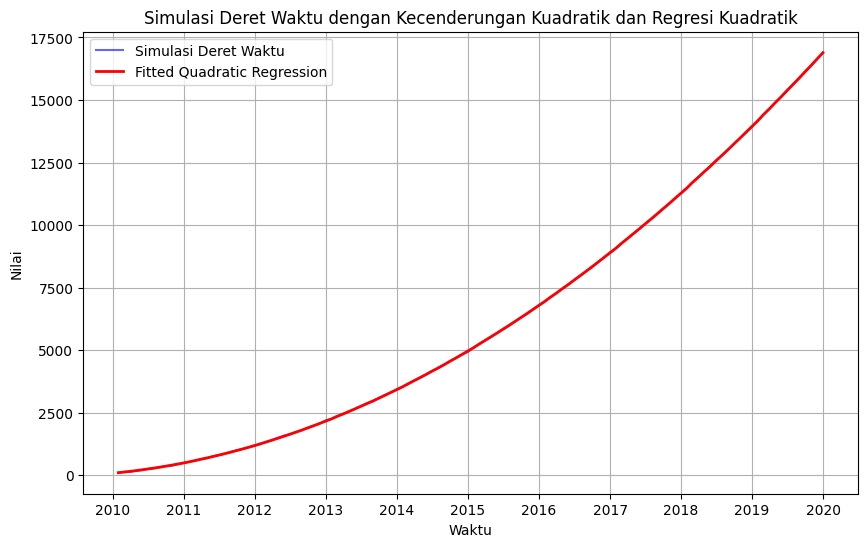

In [202]:
# Prediksi menggunakan model yang sudah dilatih
data_pred = model_quad.predict(X)

# Plot hasil simulasi deret waktu dan regresi kuadratik
plt.figure(figsize=(10, 6))
plt.plot(df_quad.Date, df_quad['Value'], label='Simulasi Deret Waktu', color='blue', alpha=0.6)
plt.plot(df_quad.Date, data_pred, label='Fitted Quadratic Regression', color='red', linewidth=2)
plt.title('Simulasi Deret Waktu dengan Kecenderungan Kuadratik dan Regresi Kuadratik')
plt.xlabel('Waktu')
plt.ylabel('Nilai')
plt.legend()
plt.grid(True)
plt.show()

**Cek apakah model regresi kuadratik yang dipaskan terhadap sudah memenuhi asumsi-asumsi model!**

Berdasarkan hasil pemeriksaan asumsi model, regresi kuadratik yang dipaskan telah memenuhi asumsi utama regresi. Residual tidak menunjukkan adanya autokorelasi, tersebar secara acak di sekitar nol, dan memiliki pola distribusi yang mendekati normal. Dengan demikian, model regresi kuadratik dapat digunakan untuk menggambarkan pola kecenderungan pada deret waktu tersebut.

**Apakah model yang dipaskan terhadap deret sudah tepat? Jelaskan jawaban Anda!**

Berdasarkan hasil pengepasan model regresi kuadratik, model dapat dikatakan sudah tepat dalam menggambarkan pola deret waktu. Hal ini terlihat dari grafik, di mana hasil prediksi regresi kuadratik hampir mengikuti pola deret simulasi (tidak terlihat selisih antara kedua pola) dan mampu menangkap pola kenaikan yang semakin cepat akibat adanya komponen kuadrat $(t^2)$.

Ketepatan model juga didukung oleh hasil estimasi parameter yang mendekati nilai asli pembangkitan data. Parameter asli yang digunakan adalah $(\beta_0=99)$, $(\beta_1=24.5)$, dan $(\beta_2=0.98)$, sedangkan hasil estimasi model adalah $(\hat{\beta}_0=98.2173)$, $(\hat{\beta}_1=24.6163)$, dan $(\hat{\beta}_2=0.9789)$.

Selain itu, nilai $(R^2=1.000)$ menunjukkan bahwa hampir seluruh variasi data dapat dijelaskan oleh model regresi kuadratik. Dengan demikian, model regresi kuadratik sudah sesuai karena mampu menangkap pola utama deret dan menghasilkan estimasi parameter yang mendekati kondisi sebenarnya.

In [203]:
# cek asumsi model regresi kuadratik

In [204]:
from statsmodels.stats.stattools import durbin_watson
from statsmodels.stats.diagnostic import acorr_ljungbox, het_breuschpagan
import scipy.stats as stats

resid_quad = model_quad.resid

print("Durbin-Watson:", durbin_watson(resid_quad))

print("\nLjung-Box:")
print(acorr_ljungbox(resid_quad, lags=[12], return_df=True))

shapiro_stat, shapiro_p = stats.shapiro(resid_quad)
print("\nShapiro-Wilk:")
print("Statistik =", shapiro_stat)
print("p-value =", shapiro_p)

bp_quad = het_breuschpagan(resid_quad, model_quad.model.exog)
print("\nBreusch-Pagan:")
print("LM Statistic =", bp_quad[0])
print("LM p-value =", bp_quad[1])

Durbin-Watson: 2.1396636818882935

Ljung-Box:
      lb_stat  lb_pvalue
12  14.180118   0.289355

Shapiro-Wilk:
Statistik = 0.9891402368146177
p-value = 0.46071555676766157

Breusch-Pagan:
LM Statistic = 3.130275049814246
LM p-value = 0.20905926034085134


1. Uji Durbin-Watson

Diperoleh:

$$ DW = 2.1397 $$

Nilai Durbin-Watson yang mendekati 2 menunjukkan bahwa residual tidak mengalami autokorelasi yang berarti. Dengan demikian, residual antarperiode dapat dianggap cukup independen.

2. Uji Ljung-Box

Diperoleh pada lag 12:

$$ p\text{-value}=0.2894 $$

Hipotesis:

$$ H_0:\text{tidak terdapat autokorelasi residual} $$ $$ H_1:\text{terdapat autokorelasi residual} $$

Karena:

$$ 0.2894>0.05 $$

maka gagal menolak \(H_0\). Artinya, tidak terdapat cukup bukti adanya autokorelasi residual hingga lag 12, sehingga asumsi independensi residual dapat dianggap terpenuhi.

3. Uji Shapiro-Wilk

Diperoleh:

$$ W=0.9891 $$

dan

$$ p\text{-value}=0.4607 $$

Hipotesis:

$$ H_0:\text{residual berdistribusi normal} $$

Karena:

$$ 0.4607>0.05 $$

maka gagal menolak \(H_0\). Dengan demikian, residual dapat dianggap berdistribusi normal, sehingga asumsi normalitas residual terpenuhi.

4. Uji Breusch-Pagan

Diperoleh:

$$ LM=3.1303 $$

dan

$$ p\text{-value}=0.2091 $$

Hipotesis:

$$ H_0:\text{varians residual konstan (homoskedastisitas)} $$ $$ H_1:\text{terdapat heteroskedastisitas} $$

Karena:

$$ 0.2091>0.05 $$

maka gagal menolak \(H_0\). Artinya, tidak terdapat cukup bukti adanya heteroskedastisitas, sehingga varians residual dapat dianggap konstan.

Kesimpulan:

Berdasarkan hasil pengujian asumsi model regresi kuadratik, tidak ditemukan pelanggaran asumsi yang signifikan. Nilai Durbin-Watson sebesar 2.1397 dan p-value uji Ljung-Box sebesar 0.2894 menunjukkan bahwa residual tidak mengalami autokorelasi yang berarti. Uji Shapiro-Wilk menghasilkan p-value sebesar 0.4607, sehingga residual dapat dianggap berdistribusi normal. Selain itu, uji Breusch-Pagan menghasilkan p-value sebesar 0.2091, yang menunjukkan bahwa tidak terdapat indikasi heteroskedastisitas. Dengan demikian, model regresi kuadratik telah memenuhi asumsi independensi, normalitas, dan homoskedastisitas residual.

## Kecenderungan Musiman/Siklik

Misalkan suatu deret waktu memiliki nilaitengah $\mu_t$ yang didefinisikan sebagai berikut:

$\mu_t=\beta_0+\beta_1 cos(2\pi f t)+\beta_2 sin(2\pi ft)$

Deret tersebut memiliki kecenderungan kosinus yang berpola musiman.

Bentuk lain fungsi nilaitengah dari kecenderungan musiman (misalnya untuk data bulanan) adalah $\mu_t$ berupa suatu konstanta sejumlah 12 yang nilai berbeda-beda. Nilai ini diinterpretasikan sebagai nilai harapan rata-rata data untuk masing-masing bulan, atau dapat dituliskan sebagai berikut:

$\mu_t=\beta_1$ , untuk $t=1,13,25,...$
       
$\mu_t=\beta_2$ , untuk $t=2,14,26,...$

$.$

$.$

$.$

$\mu_t=\beta_{12}$ , untuk $t=12,24,36,...$


In [205]:
# Menentukan parameter simulasi
np.random.seed(1049)
n_periods = 120
beta0, beta1, beta2=50 + 49,-25 * 49, -2 * 49
freq=1/12

# Membuat komponen musiman
time = np.arange(n_periods)
seasonal_component = beta0+ beta1*np.cos(2*np.pi*time*freq)+beta2*np.sin(2*np.pi*time*freq)

# Menambahkan noise acak
noise = np.random.normal(0, 2, n_periods)

# Simulasi data dengan hanya komponen musiman dan noise (tanpa tren)
data = seasonal_component + noise

# Membuat index waktu (misalnya menggunakan bulan)
dates = pd.date_range(start='2010-01-01', periods=n_periods, freq='M')

# Membuat DataFrame untuk mempermudah analisis dan visualisasi
df_seasonal = pd.DataFrame({'Date': dates, 'Value': data})


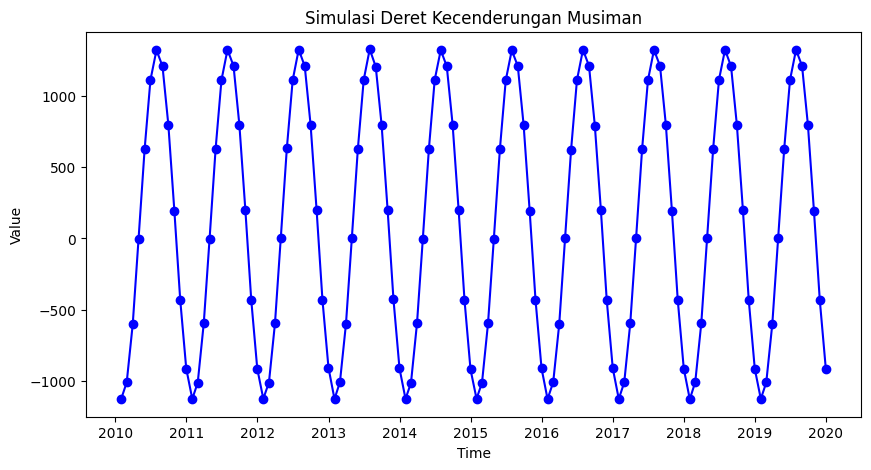

In [206]:
# Plot data deret waktu
plt.figure(figsize=(10, 5))
plt.plot(df_seasonal["Date"], df_seasonal["Value"],'-ob')
plt.xlabel("Time")
plt.ylabel("Value")
plt.title("Simulasi Deret Kecenderungan Musiman")
plt.show()


**Misalkan deret tersebut merupakan deret musiman dengan periode musiman 12. Bagaimana Anda menginterpretasikan pola yang terlihat dalam deret tersebut?**

Pada grafik terlihat adanya pola naik dan turun yang berulang dari waktu ke waktu. Nilai deret mengalami peningkatan hingga mencapai titik puncak, kemudian menurun hingga mencapai titik minimum, lalu kembali meningkat pada periode berikutnya. Siklus tersebut terjadi secara konsisten selama periode pengamatan.
Periode musiman yang digunakan adalah 12, maka pola yang berulang tersebut menunjukkan bahwa terdapat pola musiman tahunan, yaitu karakteristik nilai pada suatu bulan cenderung berulang pada bulan yang sama di tahun berikutnya.

Pada setiap siklus, nilai meningkat hingga mencapai puncak sekitar periode tertentu, kemudian mengalami penurunan menuju nilai minimum,
setelah itu kembali membentuk pola yang sama pada siklus berikutnya. Hal ini menunjukkan bahwa perubahan nilai deret dominan dipengaruhi oleh komponen musiman, bukan oleh kecenderungan naik atau turun jangka panjang (trend).

In [207]:
# membuat dummy variabel musiman dalam data
from statsmodels.tsa.deterministic import Seasonality
musim= Seasonality(12, initial_period=1).in_sample(df_seasonal.index)
musim.columns=['Januari','Februari','Maret','April','Mei','Juni','Juli','Agustus','September','Oktober','November','Desember']

In [208]:
musim

,Januari,Februari,Maret,April,Mei,Juni,Juli,Agustus,September,Oktober,November,Desember
0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
115,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
116,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
117,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
118,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [209]:
# pengepasan model regresi tanpa intercept
musiman=sm.OLS(df_seasonal["Value"],musim).fit()

In [210]:
print(musiman.summary())

                            OLS Regression Results                            
Dep. Variable:                  Value   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 1.754e+06
Date:                Sat, 05 Sep 2026   Prob (F-statistic):          3.62e-278
Time:                        14:43:07   Log-Likelihood:                -256.77
No. Observations:                 120   AIC:                             537.5
Df Residuals:                     108   BIC:                             571.0
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Januari    -1126.1138      0.685  -1643.147      0.0

Bagaimana interpretasi dari hasil tersebut?

Berdasarkan hasil regresi musiman dengan periode 12, model memiliki $(R^2=1.000)$ dalam pembulatan tiga angka desimal, sehingga hampir seluruh variasi nilai deret dapat dijelaskan oleh perbedaan pola antarbulan. Koefisien bulanan menunjukkan pola musiman yang sangat kuat. Nilai rata-rata tertinggi terjadi pada bulan Juli, yaitu sekitar 1323.72, sedangkan nilai rata-rata terendah terjadi pada bulan Januari, yaitu sekitar −1126.11. Nilai deret secara umum meningkat dari awal tahun hingga mencapai puncak sekitar Juli, kemudian kembali menurun hingga akhir tahun, dan pola tersebut berulang pada periode berikutnya.

Hampir seluruh koefisien bulan signifikan pada taraf 5%. Namun, koefisien bulan April memiliki p-value sebesar 0.079, sehingga tidak signifikan pada taraf 5%. Nilai Durbin-Watson sebesar 2.130 yang mendekati nilai 2 menunjukkan bahwa residual tidak mengalami autokorelasi yang signifikan, sehingga tidak terdapat hubungan sistematis antar kesalahan prediksi pada periode yang berbeda. Nilai probabilitas Jarque-Bera sebesar 0.287 yang lebih dari p-value 0.05 menunjukkan bahwa residual tidak mengalami penyimpangan yang signifikan dari distribusi normal. Dengan demikian, model regresi musiman yang dihasilkan sudah sesuai untuk menggambarkan deret waktu tersebut karena mampu menangkap pola musiman periode 12 dengan baik, sebagian besar koefisien musiman signifikan, serta residual memenuhi asumsi normalitas.

In [211]:
# Analisis Sisaan
# mendapatkan sisaan terbakukan
influence=musiman.get_influence()
std_resid=influence.resid_studentized_internal

mapping={1:'$J$',2:'$F$',3:'$M$',
 4:'$A$',5:'$M$',6:'$J$',
 7:'$J$',8:'$A$',9:'$S$',
 10:'$O$',11:'$N$',12:'$D$'}

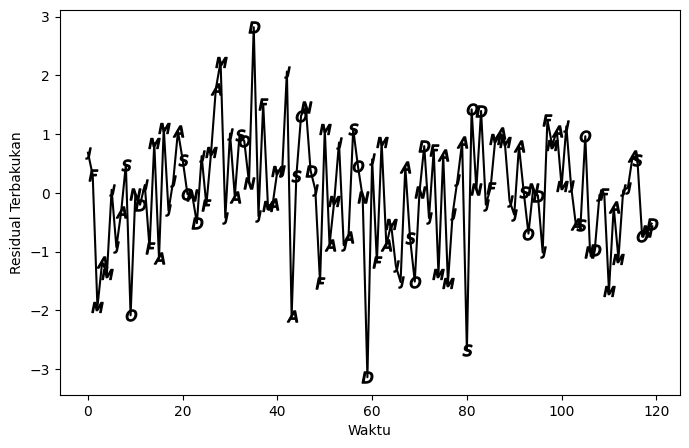

In [212]:
#memetakan sisaan dengan bentuk plot sesuai simbol bulan/musim
plt.figure(figsize=(8,5))
for i in range(len(std_resid)):
 plt.plot(i, std_resid[i], marker=mapping[i%12+1],
 color='black', markersize=8)

#membuat plot sisaan terbakukan
plt.plot(std_resid, color='black')
plt.xlabel('Waktu'), plt.ylabel('Residual Terbakukan')
plt.show()


**Bagaimana interpretasi Anda terhadap plot di atas?**

Berdasarkan plot residual terbakukan terhadap waktu, residual model terlihat menyebar secara acak di sekitar nilai nol dengan variasi yang relatif konstan sepanjang waktu. Tidak ditemukan pola tren maupun pola musiman yang tersisa pada residual. Hal ini menunjukkan bahwa model musiman telah mampu menjelaskan pola utama pada deret waktu dengan baik dan residual yang dihasilkan mendekati sifat acak (white noise).

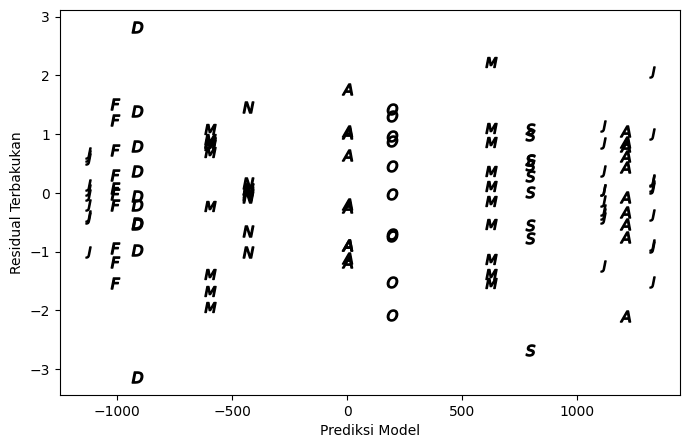

In [213]:
# membuat plot fittedvalues dengan residual terbakukan dengan simbol bulan
plt.figure(figsize=(8,5))
for i in range(len(std_resid)):
  plt.plot(musiman.fittedvalues.values[i],
           std_resid[i], marker=mapping[i%12+1],
           color='black', markersize=8)
plt.xlabel('Prediksi Model'),plt.ylabel('Residual Terbakukan')
plt.show()

**Bagaimana interpretasi Anda terhadap plot di atas?**

Berdasarkan grafik, terlihat bahwa residual terbakukan tersebar di sekitar nilai nol pada berbagai nilai prediksi model. Titik residual memiliki nilai positif dan negatif yang relatif seimbang, sehingga tidak terlihat adanya kecenderungan residual untuk selalu berada di atas atau di bawah garis nol.

Selain itu, penyebaran residual pada setiap rentang nilai prediksi model terlihat relatif konstan. Tidak terdapat pola tertentu seperti
pola melengkung ataupun pola berkelompok. Hal ini menunjukkan bahwa varians residual relatif stabil pada seluruh nilai prediksi, sehingga asumsi homoskedastisitas dapat dianggap terpenuhi.



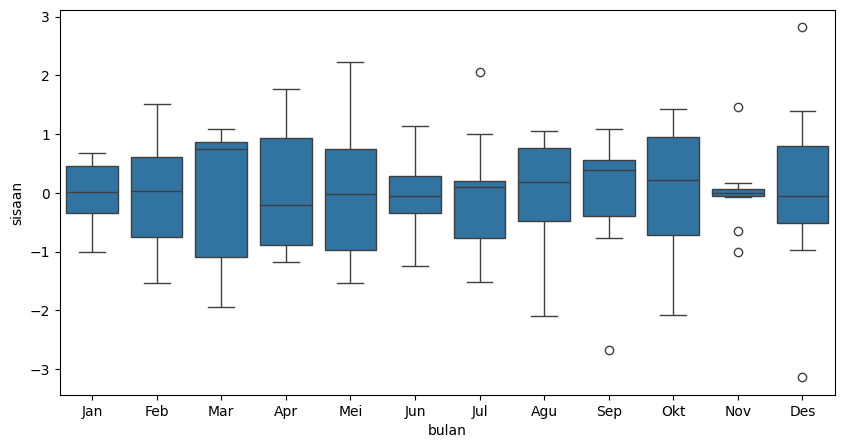

In [214]:
#membuat list daftar bulan
bulan=['Jan','Feb','Mar','Apr','Mei','Jun','Jul','Agu','Sep','Okt','Nov','Des']*10

#membuat dataframe untuk mengidentifikasi sisaan dan periode bulannya
box_sisaan=pd.DataFrame(zip(bulan[:-1], std_resid),
columns=['bulan','sisaan'])

#membuat boxplot per buln
plt.figure(figsize=(10,5))
sns.boxplot(x='bulan',y='sisaan',data=box_sisaan)
plt.show()

**Bagaimana interpretasi Anda terhadap plot di atas?**

Berdasarkan grafik, terlihat bahwa distribusi residual pada setiap bulan cenderung berada di sekitar nilai nol. Begitupun dengan median, di mana  sebagian besar bulan berada dekat dengan garis nol. Penyebaran residual antarbulan terlihat bervariasi. Beberapa bulan seperti Maret, April, Mei, dan Oktober memiliki rentang residual (box dan whisker) yang lebih lebar dibandingkan bulan lainnya. Hal ini menunjukkan bahwa kesalahan prediksi pada bulan-bulan tersebut lebih bervariasi. Sebaliknya, bulan seperti November memiliki penyebaran residual yang lebih sempit, yang menunjukkan bahwa prediksi model pada bulan tersebut lebih konsisten.

Selain itu, terdapat beberapa titik pencilan residual pada beberapa bulan, seperti:

*   September dengan residual negatif sekitar -2.7
*   Desember dengan residual negatif sekitar -3.1 dan positif sekitar 2.8
*   November dengan beberapa residual ekstrem

Nilai ekstrem tersebut menunjukkan adanya beberapa periode tertentu di mana nilai aktual cukup berbeda dari nilai yang diprediksi oleh model. Namun, karena jumlahnya relatif sedikit, pencilan tersebut tidak mengindikasikan adanya masalah serius pada model.

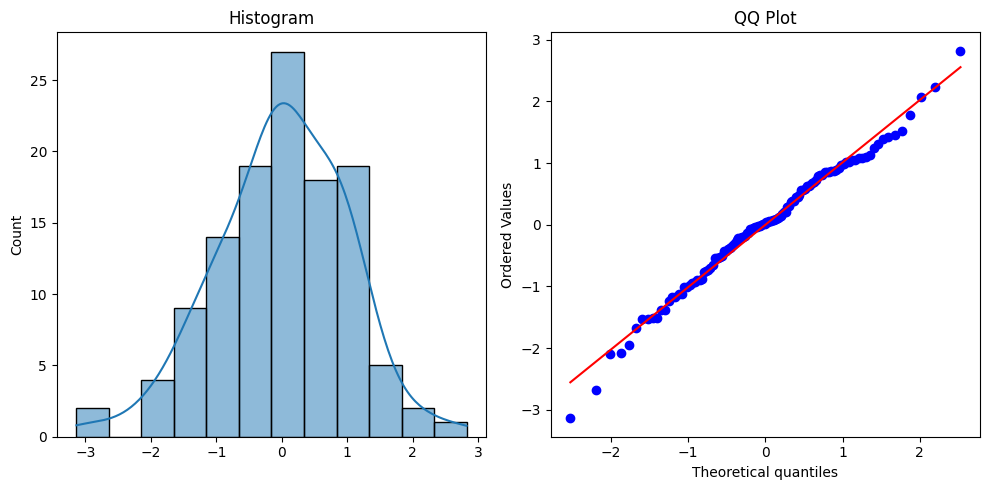

In [215]:
# Histogram Residuals
import scipy.stats as stats
fig, axes = plt.subplots(1, 2, figsize=(10,5))
# Histogram
sns.histplot(std_resid, kde=True, ax=axes[0])
axes[0].set_title('Histogram')

# QQ Plot
stats.probplot(std_resid, dist="norm", plot=axes[1])
axes[1].set_title('QQ Plot')

plt.tight_layout()
plt.show()

**Berdasarkan plot-plot tersebut apakah dapat dikatakan bahwa model yang dipaskan sudah tepat?**

Berdasarkan histogram residual dan QQ Plot, model regresi musiman yang dipaskan dapat dikatakan sudah cukup tepat dalam menggambarkan pola data. Histogram residual menunjukkan bahwa residual tersebar di sekitar nilai nol dan memiliki bentuk sebaran yang mendekati distribusi normal. Selain itu, titik-titik pada QQ Plot cenderung berada di sekitar garis diagonal, yang menunjukkan bahwa residual memiliki kesesuaian dengan distribusi normal, meskipun terdapat sedikit penyimpangan pada bagian ujung distribusi.

Hasil tersebut menunjukkan bahwa model telah mampu menangkap pola utama pada data, yaitu pola musiman dengan periode 12, sehingga residual yang tersisa tidak lagi menunjukkan pola tertentu. Dengan demikian, model regresi musiman dapat dianggap sesuai untuk menjelaskan variasi pada deret waktu tersebut.


Hitunglah statistik uji untuk mengecek asumsi model



In [216]:
# hitung statistik uji untuk mengecek asumsi model tanpa intersep

In [217]:
from statsmodels.stats.stattools import durbin_watson
from statsmodels.stats.diagnostic import acorr_ljungbox, het_breuschpagan
import scipy.stats as stats
import statsmodels.api as sm

# Residual dari model tanpa intersep
resid_musiman = musiman.resid


# 1. Uji Durbin-Watson
dw = durbin_watson(resid_musiman)

print("Uji Durbin-Watson")
print("Statistik =", dw)


# 2. Uji Ljung-Box pada lag 12
ljung_box = acorr_ljungbox(
    resid_musiman,
    lags=[12],
    return_df=True
)

print("\nUji Ljung-Box")
print(ljung_box)


# 3. Uji Shapiro-Wilk untuk normalitas
shapiro_stat, shapiro_p = stats.shapiro(resid_musiman)

print("\nUji Shapiro-Wilk")
print("Statistik =", shapiro_stat)
print("p-value =", shapiro_p)


# 4. Uji Breusch-Pagan untuk homoskedastisitas
# Dibuat konstanta + 11 dummy bulan agar matriks memiliki intercept
X_bp = sm.add_constant(musim.iloc[:, 1:])

bp_test = het_breuschpagan(
    resid_musiman,
    X_bp
)

print("\nUji Breusch-Pagan")
print("LM Statistic =", bp_test[0])
print("LM p-value =", bp_test[1])

Uji Durbin-Watson
Statistik = 2.130439763728806

Uji Ljung-Box
      lb_stat  lb_pvalue
12  20.727423   0.054517

Uji Shapiro-Wilk
Statistik = 0.9900429386977412
p-value = 0.5381591578420089

Uji Breusch-Pagan
LM Statistic = 12.639863846063442
LM p-value = 0.3175137282412677


1. Uji Durbin-Watson

Diperoleh:

$$ DW = 2.1304 $$

Nilai Durbin-Watson yang mendekati 2 menunjukkan bahwa residual tidak mengalami autokorelasi yang berarti. Dengan demikian, residual antarperiode dapat dianggap cukup independen.

2. Uji Ljung-Box

Diperoleh pada lag 12:

$$ p\text{-value}=0.0545 $$

Dengan hipotesis:

$$ H_0:\text{tidak terdapat autokorelasi residual} $$ $$ H_1:\text{terdapat autokorelasi residual} $$

Karena:

$$ 0.0545>0.05 $$

maka gagal tolak \(H_0\). Artinya, tidak terdapat cukup bukti untuk menyatakan bahwa residual memiliki autokorelasi hingga lag 12 pada taraf signifikansi 5%.

3. Uji Shapiro-Wilk

Diperoleh:

$$ W=0.9900 $$

dan

$$ p\text{-value}=0.5382 $$

Hipotesisnya:

$$ H_0:\text{residual berdistribusi normal} $$

Karena:

$$ 0.5382>0.05 $$

maka gagal menolak \(H_0\). Dengan demikian, residual dapat dianggap berdistribusi normal, sehingga asumsi normalitas residual terpenuhi.

4. Uji Breusch-Pagan

Diperoleh:

$$ LM=12.6399 $$

dan

$$ p\text{-value}=0.3175 $$

Hipotesis:

$$ H_0:\text{varians residual konstan (homoskedastisitas)} $$ $$ H_1:\text{terdapat heteroskedastisitas} $$

Karena:

$$ 0.3175>0.05 $$

maka gagal tolak \(H_0\). Artinya, tidak terdapat cukup bukti adanya heteroskedastisitas, sehingga varians residual dapat dianggap konstan.



---



In [218]:
# pengepasan model regresi dengan intersep
musiman_int=sm.OLS(df_seasonal["Value"],sm.add_constant(musim.iloc[:,1:])).fit()

In [219]:
print(musiman_int.summary())

                            OLS Regression Results                            
Dep. Variable:                  Value   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 1.754e+06
Date:                Sat, 05 Sep 2026   Prob (F-statistic):          3.62e-278
Time:                        14:43:09   Log-Likelihood:                -256.77
No. Observations:                 120   AIC:                             537.5
Df Residuals:                     108   BIC:                             571.0
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -1126.1138      0.685  -1643.147      0.0

**Perhatikan hasil pengepasan model dengan intersep. Bandingkan hasilnya dengan pengepasan tanpa intersep. Bagaimana interpretasi model dengan intersep dibandingkan model tanpa intersep? Jelaskan cara memaknai nilai koefisien regresi yang diperoleh!**



---


1. Perbandingan hasil pengepasan model dengan intercept dan tanpa intercept

Pada model tanpa intercept, setiap koefisien bulan secara langsung menggambarkan rata-rata nilai deret pada bulan tersebut. Dengan kata lain, koefisien Januari menunjukkan rata-rata nilai pada bulan Januari, koefisien Februari menunjukkan rata-rata nilai pada bulan Februari, dan seterusnya. Misalnya, hasil model tanpa intersep menunjukkan rata-rata nilai pada bulan Januari sebesar -1126.1138, Februari sebesar -1010.5640, Maret sebesar -597.7757, dan September sebesar 797.1393.

Sedangkan pada model dengan intersep, model menggunakan bulan Januari sebagai kategori referensi (baseline). Oleh karena itu, koefisien bulan lainnya menunjukkan perbedaan nilai bulan tersebut dibandingkan dengan bulan Januari.

Pada hasil model dengan intersep:

- Intercept = -1126.1138 → nilai rata-rata deret pada bulan Januari.
- Koefisien Februari = 115.5498 → nilai Februari sekitar 115.55 unit lebih tinggi dibanding Januari.
- Koefisien Maret = 528.3381 → nilai Maret sekitar 528.34 unit lebih tinggi dibanding Januari.
- Koefisien Juni = 2237.7769 → nilai Juni sekitar 2237.78 unit lebih tinggi dibanding Januari.
- Koefisien September = 1923.2531 → nilai September sekitar 1923.25 unit lebih tinggi dibanding Januari.

Hubungan kedua model dapat dilihat langsung.

Untuk Februari:
$$ -1126.1138+115.5498=-1010.5640 $$

yang sama dengan koefisien Februari pada model tanpa intersep, yaitu -1010.5640.

Untuk September:
$$ -1126.1138+1923.2531=797.1393 $$

yang sama dengan koefisien September pada model tanpa intersep, yaitu 797.1393.

Dengan demikian, kedua model menghasilkan fitted value dan informasi musiman yang sama, tetapi cara interpretasinya berbeda. Model tanpa intercept memberikan nilai rata-rata langsung untuk setiap bulan, sedangkan model dengan intercept memberikan perbedaan setiap bulan terhadap bulan referensi, yaitu Januari.

---

2. Bagaimana interpretasi model dengan intercept dibandingkan model tanpa intercept?

Perbedaan utama kedua model terletak pada cara interpretasi koefisien:

- Model tanpa intercept
  - Setiap koefisien bulan menunjukkan nilai rata-rata langsung pada bulan tersebut.
  - Lebih mudah digunakan untuk menginterpretasikan pola musiman karena setiap bulan memiliki nilai sendiri.

- Model dengan intercept
  - Satu bulan harus menjadi kategori referensi (dalam kasus ini Januari).
  - Intercept menunjukkan nilai dasar Januari.
  - Koefisien bulan menunjukkan perubahan nilai relatif terhadap Januari.

Lebih singkatnya, model tanpa intercept menghitung:

"Nilai rata-rata setiap bulan?"

Sedangkan model dengan intercept menghitung:

"Seberapa besar perbedaan setiap bulan dibandingkan bulan referensi?"

Ukuran kecocokan modelnya juga sama: keduanya memiliki $(R^2=1.000)$, log-likelihood, AIC, BIC, dan diagnostik residual yang sama, karena secara substansi keduanya merepresentasikan pola musiman yang sama.

---

3. Bagaimana cara memahami nilai koefisien regresi yang diperoleh?

Pada model dengan intercept, interpretasi koefisien dilakukan relatif terhadap bulan Januari.

Contohnya:

Intercept:
$$ \beta_0=-1126.1138 $$

Artinya, ketika periode berada pada bulan Januari, nilai prediksi deret adalah sekitar 122.89.

Koefisien Februari:
$$ \beta_{Februari}=115.5498 $$

Artinya, nilai deret pada bulan Februari diperkirakan 20.7155 unit lebih tinggi dibandingkan Januari.

Sehingga:

$$ Y_{Februari}=−1126.1138+115.5498=−1010.5640 $$
Koefisien Desember:
$$ \beta_{Desember}=213.3838 $$

Artinya, nilai Desember diperkirakan 26.4504 unit lebih rendah dibandingkan Januari.

Sehingga:

$$ Y_{Desember}=−1126.1138+213.3838=−912.7300 $$

---

**Apakah model dengan intersep sudah memenuhi asumsi regresi?**

Berdasarkan output model dengan intercept:

- $(R^2=1.000)$ menunjukkan bahwa model mampu menjelaskan sekitar 100% variasi data.

- Durbin-Watson:
$$ DW=2.130 $$

Nilai tersebut mendekati 2, sehingga menunjukkan bahwa residual dianggap tidak mengalami autokorelasi.

- Jarque-Bera:
$$ p\text{-value}=0.287 $$

Karena $(p\text{-value}>0.05)$, maka residual dapat dianggap berdistribusi normal.

Dengan demikian, model regresi musiman dengan intercept telah memenuhi asumsi dasar regresi. Model mampu menjelaskan pola musiman dengan baik, residual tidak menunjukkan autokorelasi, dan residual memenuhi asumsi normalitas.

In [220]:
# uji asumsi model dengan intersep

In [245]:
resid_int = musiman_int.resid

print("Durbin-Watson:", durbin_watson(resid_int))

print("\nLjung-Box:")
print(acorr_ljungbox(resid_int, lags=[12], return_df=True))

shapiro_stat, shapiro_p = stats.shapiro(resid_int)
print("\nShapiro-Wilk:")
print("Statistik =", shapiro_stat)
print("p-value =", shapiro_p)

bp_int = het_breuschpagan(
    resid_int,
    musiman_int.model.exog
)

print("\nBreusch-Pagan:")
print("LM Statistic =", bp_int[0])
print("LM p-value =", bp_int[1])

Durbin-Watson: 2.130439763728798

Ljung-Box:
      lb_stat  lb_pvalue
12  20.727423   0.054517

Shapiro-Wilk:
Statistik = 0.9900429386977404
p-value = 0.5381591578419449

Breusch-Pagan:
LM Statistic = 12.639863846063975
LM p-value = 0.3175137282412309


1. Uji Durbin-Watson

Diperoleh:

$$ DW = 2.1304 $$

Nilai Durbin-Watson mendekati 2, sehingga menunjukkan bahwa residual tidak mengalami autokorelasi yang berarti. Dengan demikian, residual antarperiode dapat dianggap cukup independen.

2. Uji Ljung-Box

Diperoleh pada lag 12:

$$ p\text{-value}=0.0545 $$

Hipotesis:

$$ H_0:\text{tidak terdapat autokorelasi residual} $$ $$ H_1:\text{terdapat autokorelasi residual} $$

Karena:

$$ 0.0545>0.05 $$

maka gagal menolak \(H_0\). Artinya, tidak terdapat cukup bukti untuk menyatakan adanya autokorelasi residual hingga lag 12 pada taraf signifikansi 5%.

Karena nilainya cukup dekat dengan 0.05, lebih aman menulis “tidak terdapat cukup bukti adanya autokorelasi”, bukan “sama sekali tidak ada autokorelasi”.

3. Uji Shapiro-Wilk

Diperoleh:

$$ W=0.9900 $$

dan

$$ p\text{-value}=0.5382 $$

Karena:

$$ 0.5382>0.05 $$

maka gagal menolak \(H_0\). Dengan demikian, residual dapat dianggap berdistribusi normal, sehingga asumsi normalitas residual terpenuhi.

4. Uji Breusch-Pagan

Diperoleh:

$$ LM=12.6399 $$

dan

$$ p\text{-value}=0.3175 $$

Karena:

$$ 0.3175>0.05 $$

maka gagal menolak \(H_0\). Artinya, tidak terdapat cukup bukti adanya heteroskedastisitas, sehingga varians residual dapat dianggap konstan atau homoskedastik.

Kesimpulan:

Berdasarkan hasil pengujian asumsi model musiman dengan intersep, tidak ditemukan pelanggaran asumsi yang berarti. Nilai Durbin-Watson sebesar 2.1304 dan p-value uji Ljung-Box sebesar 0.0545 menunjukkan bahwa tidak terdapat cukup bukti adanya autokorelasi residual. Uji Shapiro-Wilk menghasilkan p-value sebesar 0.5382, sehingga residual dapat dianggap berdistribusi normal. Selain itu, uji Breusch-Pagan menghasilkan p-value sebesar 0.3175, sehingga tidak terdapat indikasi heteroskedastisitas. Dengan demikian, model musiman dengan intersep telah memenuhi asumsi independensi, normalitas, dan homoskedastisitas residual.

## Kecenderungan Linear dan Musiman

In [221]:
# Parameter
np.random.seed(1049)
n = 100  # Jumlah titik data
x = np.arange(n)

# Komponen trend linear
a, b = 0.5 * 49, 10 * 49 #(slope dan intersep)
trend = a * x + b

# Komponen musiman (sinusoidal)
seasonality = 5 * np.sin(2 * np.pi * x / 12)

# Noise acak
noise = np.random.normal(scale=2, size=n)

# Gabungan semua komponen
series = trend + seasonality + noise


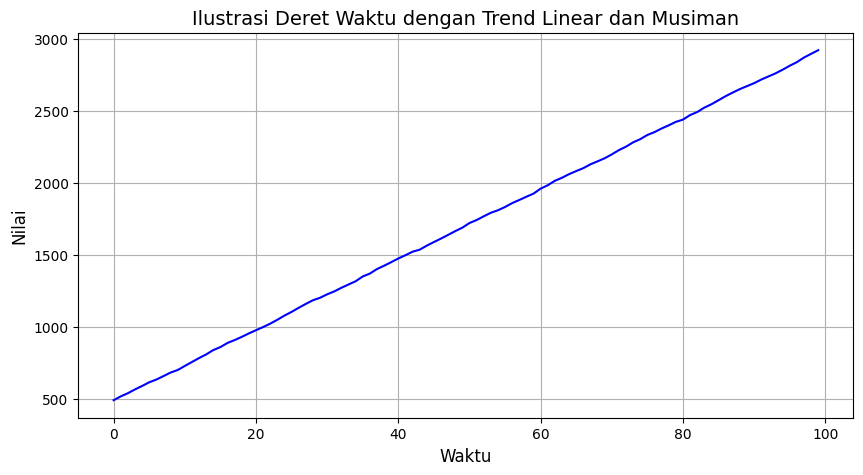

In [222]:
plt.figure(figsize=(10, 5))
plt.plot(x, series, color='b')
plt.xlabel('Waktu', fontsize=12)
plt.ylabel('Nilai', fontsize=12)
plt.title('Ilustrasi Deret Waktu dengan Trend Linear dan Musiman', fontsize=14)
plt.grid()
plt.show()

Untuk deret tersebut, dibutuhkan model yang mampu menangkap kecenderungan linear (tren) sekaligus kecenderungan musiman dalam deret. Salah satu model sederhana yang dapat digunakan adalah model regresi linear dengan variabel musiman.

In [223]:
# mengubah data menjadi format dataframe
df_mix = pd.DataFrame(series, columns=['Value'])

# mengekstrak komponen musiman dalam data
from statsmodels.tsa.deterministic import Seasonality
season= Seasonality(12, initial_period=1).in_sample(df_mix.index)
season.columns=['Januari','Februari','Maret','April','Mei','Juni','Juli','Agustus','September','Oktober','November','Desember']

In [224]:
season['period']=x

model_mix=sm.OLS(series,season).fit()

In [225]:
print(model_mix.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 7.953e+05
Date:                Sat, 05 Sep 2026   Prob (F-statistic):          1.02e-213
Time:                        14:43:09   Log-Likelihood:                -217.74
No. Observations:                 100   AIC:                             461.5
Df Residuals:                      87   BIC:                             495.4
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Januari      489.7960      0.853    574.148      0.0

Bagaimana cara menginterpretasikan nilai koefisien regresi yang diperoleh dalam model regresi tersebut?

Berdasarkan output diperoleh:

$$ R^2=1.000 $$

Artinya, 100% variasi (jika menggunakan 3 digit setelah koma) nilai deret dapat dijelaskan oleh model, baik melalui komponen musiman maupun komponen waktu. Nilai $(R^2)$ yang sangat tinggi menunjukkan bahwa kombinasi antara pola musiman bulanan dan perubahan waktu mampu menggambarkan pola data dengan sangat baik.

Setiap koefisien bulan menunjukkan nilai dasar deret pada bulan tersebut setelah mempertimbangkan pengaruh waktu. Koefisien bulanan berada pada kisaran sekitar 484–495. Nilai terbesar terdapat pada Mei, yaitu sekitar 495.25, sedangkan nilai terendah terdapat pada November, yaitu sekitar 484.57. Perbedaan tersebut menunjukkan adanya variasi musiman antarbulan.


Koefisien periode yang dihasilkan adalah $$ \beta_1=24.5020 $$

Nilai positif pada koefisien menunjukkan adanya kecenderungan peningkatan nilai deret dari waktu ke waktu. Setiap bertambah satu periode waktu, nilai deret diperkirakan meningkat sekitar 24.50 unit setelah mempertimbangkan pengaruh musiman.

Selain itu, baik pada koefisien tiap bulan maupun koefisien periode memiliki $ p\text{-value}=0.000$ yang kurang dari alpha (0.05). Hal ini berarti baik komponen musiman maupun komponen waktu ymemberikan pengaruh yang signifikan terhadap nilai deret.

Dari hasil diagnostik:

- Durbin-Watson:

$$ DW=2.168 $$

Nilai yang dihasilkan mendekati 2, sehingga menunjukkan bahwa residual dianggap tidak mengalami autokorelasi.

- Jarque-Bera:

$$ p\text{-value}=0.136 $$

Karena $ p-value>0.05 $, maka residual dapat dianggap berdistribusi normal.

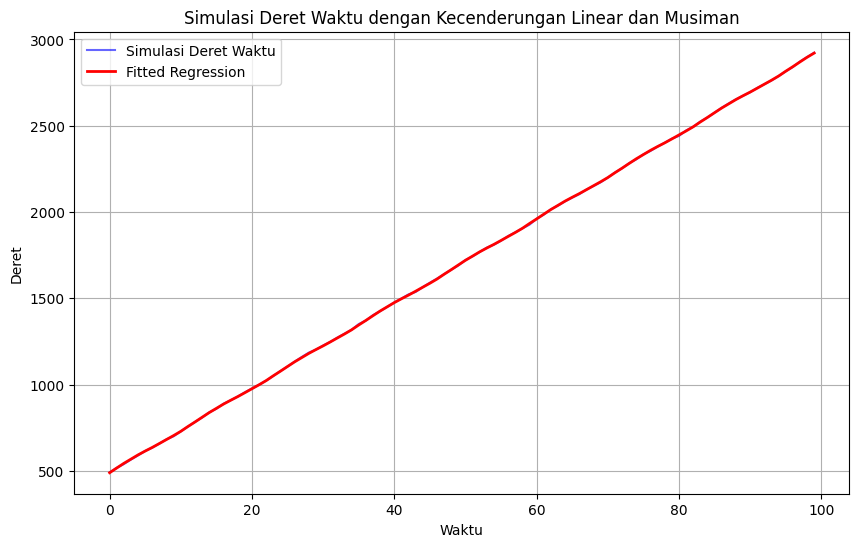

In [226]:
# Prediksi menggunakan model yang sudah dilatih
pred_mix = model_mix.predict(season)

# Plot hasil simulasi deret waktu dan regresi kuadratik
plt.figure(figsize=(10, 6))
plt.plot(x, series, label='Simulasi Deret Waktu', color='blue', alpha=0.6)
plt.plot(x, pred_mix, label='Fitted Regression', color='red', linewidth=2)
plt.title('Simulasi Deret Waktu dengan Kecenderungan Linear dan Musiman')
plt.xlabel('Waktu')
plt.ylabel('Deret')
plt.legend()
plt.grid(True)
plt.show()

Lakukan pengecekan asumsi model! Jelaskan apakah hasil menunjukkan ada pelanggaran asumsi dalam model!

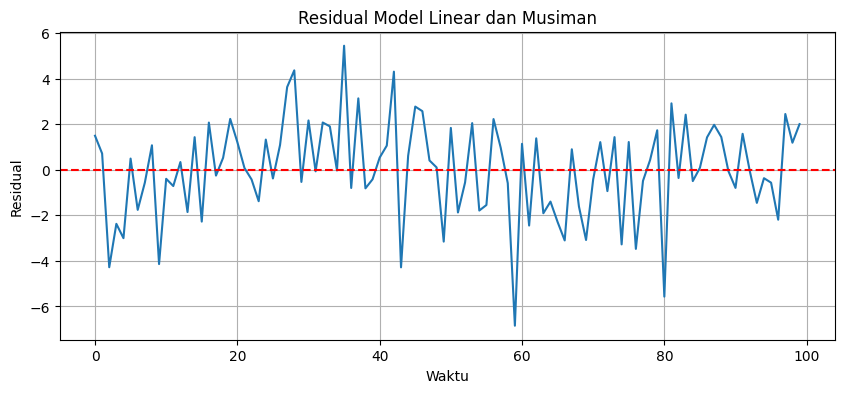

In [227]:
# Plot residual terhadap waktu

residual_mix = model_mix.resid
plt.figure(figsize=(10,4))

plt.plot(x, residual_mix)

plt.axhline(0, color='red', linestyle='--')

plt.title("Residual Model Linear dan Musiman")
plt.xlabel("Waktu")
plt.ylabel("Residual")

plt.grid(True)
plt.show()

Hasil plot:

- Residual terlihat berfluktuasi di sekitar garis nol.
- Tidak terlihat adanya pola tertentu seperti tren meningkat/menurun atau pola musiman yang masih tersisa.
- Hanya terdapat beberapa nilai ekstrem (misalnya sekitar periode 60 dan 80).

Kesimpulan:

Berdasarkan plot residual terhadap waktu, residual model terlihat menyebar secara acak di sekitar nilai nol tanpa membentuk pola tertentu. Hal ini menunjukkan bahwa model regresi linear dan musiman telah mampu menangkap komponen utama dalam deret, yaitu kecenderungan linear dan pola musiman. Tidak terlihat adanya pola sistematis yang tersisa pada residual, sehingga tidak terdapat indikasi bahwa model masih belum menangkap struktur penting dari data.

<Figure size 800x400 with 0 Axes>

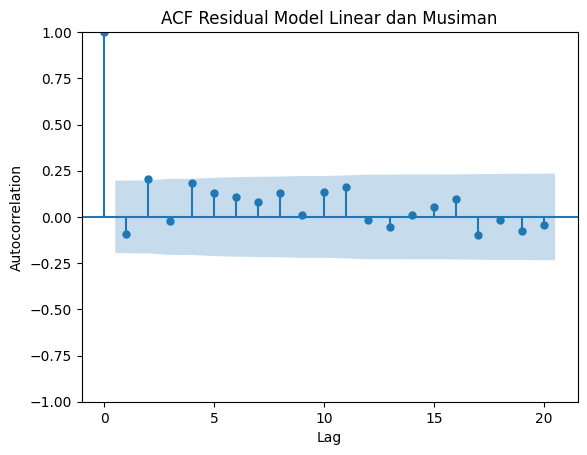

In [228]:
# Plot ACF

from statsmodels.graphics.tsaplots import plot_acf

plt.figure(figsize=(8,4))

plot_acf(residual_mix, lags=20)

plt.title("ACF Residual Model Linear dan Musiman")

plt.xlabel("Lag")
plt.ylabel("Autocorrelation")

plt.show()

Hasil plot:

- Hampir seluruh nilai autokorelasi pada berbagai lag berada di dalam batas interval kepercayaan.
- Nilai autokorelasi terbesar hanya muncul pada lag kecil dan masih berada dalam batas yang dapat diterima.

Kesimpulan:

Berdasarkan plot ACF residual, nilai autokorelasi pada setiap lag berada dalam batas interval kepercayaan. Hal ini menunjukkan bahwa residual tidak memiliki hubungan yang signifikan antarperiode waktu. Dengan demikian, residual dapat dianggap mendekati sifat white noise, sehingga asumsi independensi residual terpenuhi. Tidak terdapat indikasi adanya autokorelasi yang belum dijelaskan oleh model.

In [229]:
# Uji Durbin Watson

from statsmodels.stats.stattools import durbin_watson

dw_mix = durbin_watson(residual_mix)

print("Nilai Durbin-Watson:", dw_mix)

Nilai Durbin-Watson: 2.1682568496448784


Hasil:

$$ DW = 2.168 $$

Interpretasi nilai Durbin-Watson:
- Nilai mendekati 2 → tidak terdapat autokorelasi.
- Nilai < 2 → kecenderungan autokorelasi positif
- Nilai > 2 → kecenderungan autokorelasi negatif.

Interpretasi:

Nilai Durbin-Watson yang diperoleh sebesar 2.168 mendekati nilai 2. Hal ini menunjukkan bahwa residual dianggap tidak mengalami autokorelasi. Dengan demikian, hasil uji Durbin-Watson mendukung hasil plot ACF residual bahwa asumsi independensi error telah terpenuhi.

In [230]:
# Uji Ljung-Box

from statsmodels.stats.diagnostic import acorr_ljungbox

ljung_mix = acorr_ljungbox(
    residual_mix,
    lags=[12],
    return_df=True
)

print(ljung_mix)

      lb_stat  lb_pvalue
12  19.916027   0.068691


Hasil:

$$ p\text{-value}=0.06891 $$

Hipotesis:

$$ H_0: \text{Tidak terdapat autokorelasi residual} $$
$$ H_1: \text{Terdapat autokorelasi residual} $$

Karena:

$$ 0.06891 > 0.05 $$

maka gagal menolak $(H_0)$.

Interpretasi:

Berdasarkan uji Ljung-Box pada lag 12, diperoleh nilai p-value sebesar 0.06891 yang lebih besar dari tingkat signifikansi 5%, maka tidak terdapat cukup bukti untuk menyatakan adanya autokorelasi pada residual. Dengan demikian, residual model dianggap independen dan tidak terdapat pelanggaran asumsi independensi.

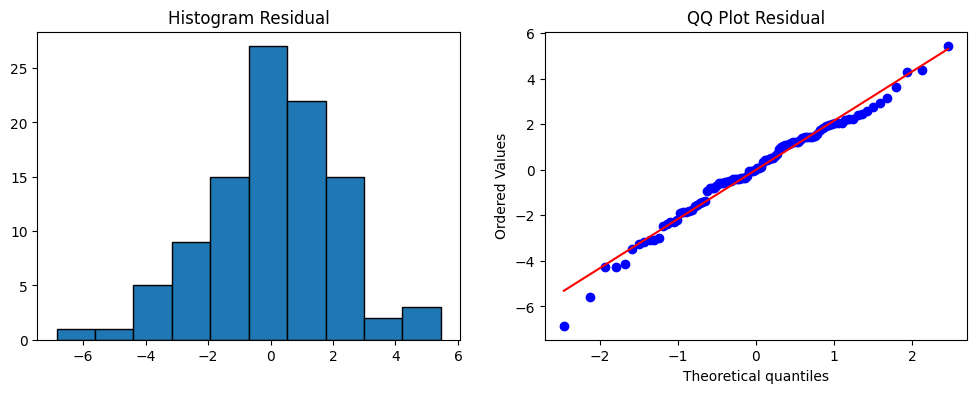

In [231]:
# Uji Normalitas

import scipy.stats as stats

fig, ax = plt.subplots(1,2, figsize=(12,4))

# Histogram
ax[0].hist(residual_mix, bins=10, edgecolor="black")
ax[0].set_title("Histogram Residual")

# QQ Plot
stats.probplot(
    residual_mix,
    dist="norm",
    plot=ax[1]
)

ax[1].set_title("QQ Plot Residual")

plt.show()

Hasil histogram:

- Residual memiliki pola yang mendekati distribusi normal.
- Sebagian besar residual berada di sekitar nilai nol.
- Terdapat sedikit residual ekstrem pada bagian ekor.

Hasil QQ Plot:

- Sebagian besar titik mengikuti garis diagonal.
- Penyimpangan hanya terlihat pada bagian ujung distribusi.

Interpretasi:

Berdasarkan histogram residual, distribusi residual terlihat cukup simetris dengan pusat penyebaran berada di sekitar nilai nol. Hal ini menunjukkan bahwa residual memiliki pola distribusi yang mendekati normal. Selain itu, pada QQ Plot sebagian besar titik berada di sekitar garis diagonal, yang menunjukkan bahwa asumsi normalitas residual telah terpenuhi. Meskipun terdapat sedikit penyimpangan pada bagian ekstrem, penyimpangan tersebut masih dalam batas wajar.

In [232]:
# uji asumsi model

Saat melihat plot dari suatu deret, terkadang kita tidak yakin komponen apa saja yang ada dalam deret. Misalkan, apakah deret tidak memuat tren? apakah ada tren? apakah ada komponen musiman? Untuk memastikan komponen apa saja yang ada dalam suatu deret, dapat dilakukan dengan dekomposisi deret. Dekomposisi deret bertujuan menguraikan deret menjadi 3 komponen, yaitu tren, musiman, dan noise.

In [233]:
# Melakukan dekomposisi untuk deret simulasi kecenderungan linear
from statsmodels.tsa.seasonal import seasonal_decompose
result = seasonal_decompose(df['Value'], model='additive', period=12)

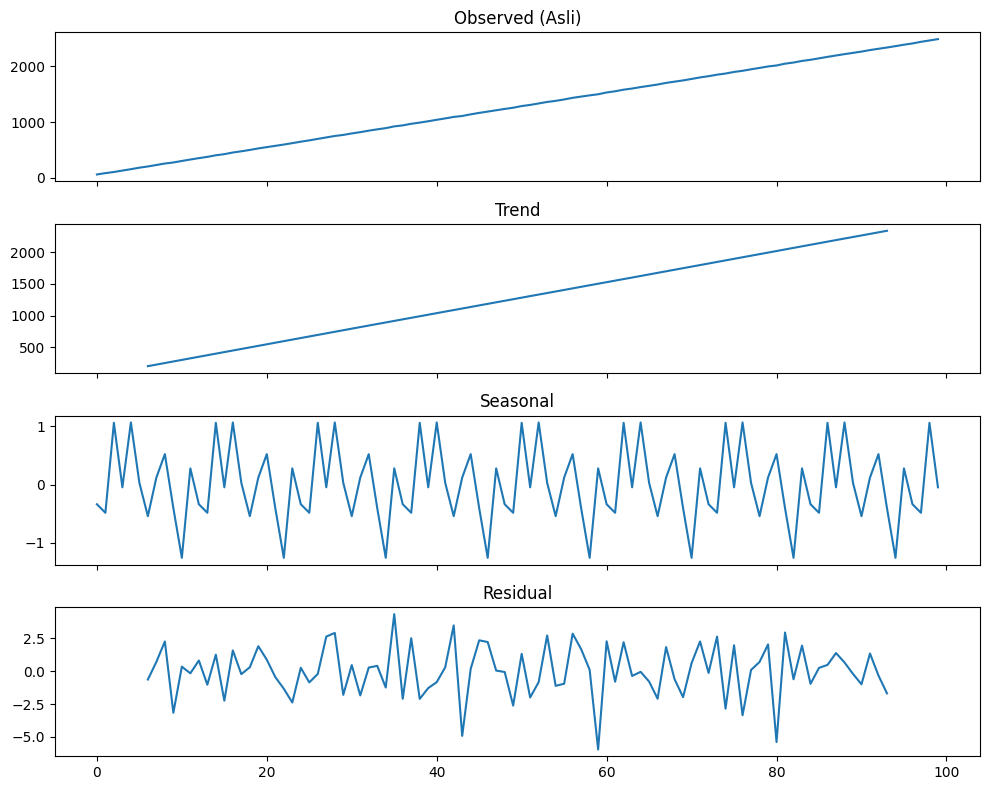

In [234]:
fig, axes = plt.subplots(4, 1, figsize=(10, 8), sharex=True)

result.observed.plot(ax=axes[0], title='Observed (Asli)')
result.trend.plot(ax=axes[1], title='Trend')
result.seasonal.plot(ax=axes[2], title='Seasonal')
result.resid.plot(ax=axes[3], title='Residual')

plt.tight_layout()
plt.show()

**Bagaimana interpretasi hasil dekomposisi deret tersebut?**

1. Komponen Observed (Data Asli)

Pada komponen observed terlihat bahwa deret mengalami peningkatan secara konsisten dari waktu ke waktu. Pola kenaikan yang hampir linear menunjukkan adanya kecenderungan trend yang kuat. Selain pola kenaikan tersebut, terdapat fluktuasi kecil di sekitar trend yang terutama berasal dari variasi acak (noise).

2. Komponen Trend

Pada komponen trend terlihat pola garis lurus yang meningkat seiring waktu. Hal ini menunjukkan bahwa terdapat kecenderungan linear pada data nyang dipengaruhi oleh faktor waktu, yaitu nilai deret mengalami peningkatan secara stabil setiap periode.


3. Komponen Seasonal (Musiman)

Komponen seasonal menunjukkan pola naik-turun yang berulang di sekitar nilai nol. Pola tersebut merupakan komponen musiman yang dihasilkan dari proses dekomposisi dengan periode yang ditentukan. Namun, besarnya fluktuasi pada plot musiman ini relatif kecil dibandingkan dengan komponen trend, sehingga komponen trend tetap lebih dominan dalam deret.

4. Komponen Residual

Komponen residual menunjukkan sisa variasi data setelah komponen trend dan musiman dihilangkan. Dari grafik terlihat bahwa residual berfluktuasi secara acak di sekitar nilai nol tanpa membentuk pola tertentu, menunjukkan bahwa model dekomposisi telah mampu menangkap pola utama dalam data. Tidak terlihat adanya pola sistematis yang tersisa pada residual.

Kesimpulan:

Berdasarkan hasil dekomposisi, deret waktu didominasi oleh komponen trend yang menunjukkan peningkatan linear sepanjang waktu. Hasil dekomposisi juga menghasilkan komponen seasonal dengan fluktuasi yang relatif kecil dibandingkan trend. Namun, karena data simulasi awal tidak secara eksplisit dibangkitkan dengan komponen musiman, komponen tersebut tidak perlu diinterpretasikan sebagai pola musiman yang kuat. Residual menunjukkan pola yang relatif acak di sekitar nol.

In [235]:
# Melakukan dekomposisi untuk deret simulasi kecenderungan linear dan musiman
from statsmodels.tsa.seasonal import seasonal_decompose
result_mix = seasonal_decompose(df_mix['Value'], model='additive', period=12)

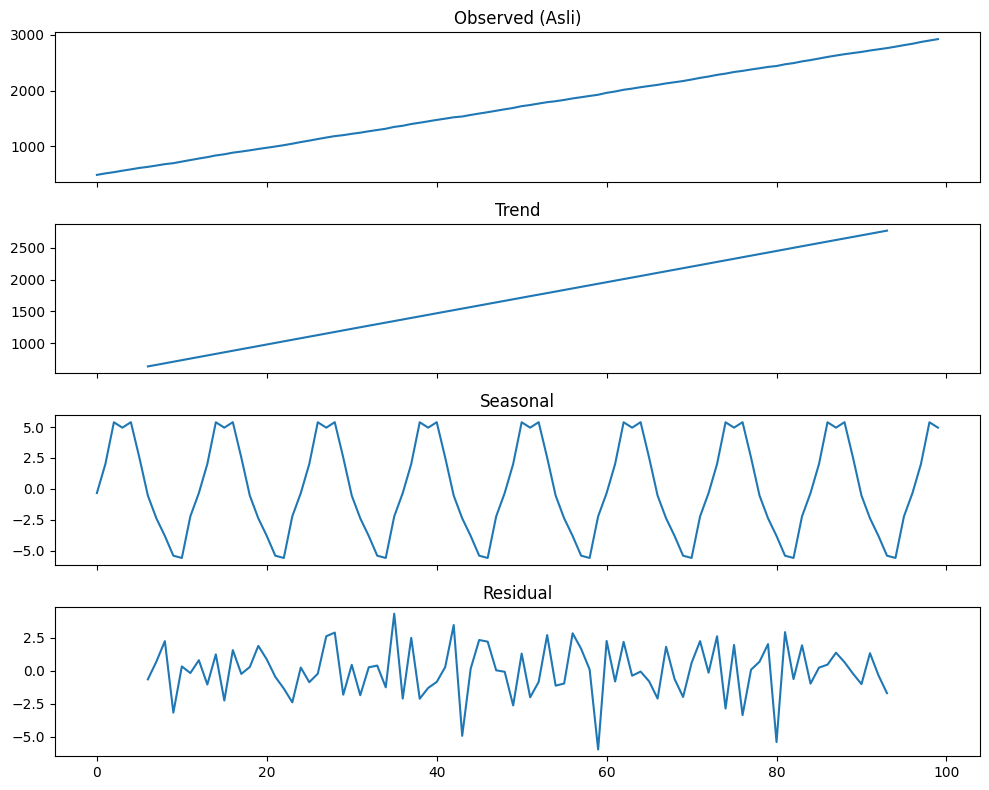

In [236]:
fig, axes = plt.subplots(4, 1, figsize=(10, 8), sharex=True)

result_mix.observed.plot(ax=axes[0], title='Observed (Asli)')
result_mix.trend.plot(ax=axes[1], title='Trend')
result_mix.seasonal.plot(ax=axes[2], title='Seasonal')
result_mix.resid.plot(ax=axes[3], title='Residual')

plt.tight_layout()
plt.show()


**Bagaimana interpretasi hasil dekomposisi deret tersebut?**

1. Komponen Observed (Data Asli)

Pada plot Observed (Asli), deret menunjukkan pola peningkatan yang hampir linear sepanjang waktu. Nilai deret terus meningkat secara konsisten dari awal hingga akhir periode pengamatan. Secara visual, tidak terlihat fluktuasi atau pola musiman yang jelas karena bentuk deret tampak sangat halus dan hampir menyerupai garis lurus.

2. Komponen Trend

Komponen trend menunjukkan adanya kecenderungan peningkatan linear yang jelas pada deret waktu. Nilai trend terus meningkat secara konsisten sepanjang periode pengamatan, sehingga menunjukkan bahwa faktor waktu memberikan pengaruh positif terhadap perubahan nilai deret. Komponen trend merupakan komponen yang paling dominan dalam menjelaskan pola data.

3. Komponen Seasonal (Musiman)

Komponen seasonal menunjukkan adanya pola musiman dengan periode 12 yang berulang secara konsisten. Pada plot Seasonal, terlihat pola naik dan turun yang berulang secara teratur. Hal ini menunjukkan bahwa terdapat pengaruh musiman dalam deret waktu, meskipun besar pengaruhnya jauh lebih kecil dibandingkan komponen trend.

4. Komponen Residual

Komponen residual menunjukkan variasi acak yang tersisa setelah pengaruh trend dan musiman dihilangkan. Residual berfluktuasi di sekitar nilai nol tanpa menunjukkan pola tertentu, sehingga menunjukkan bahwa komponen trend dan musiman telah berhasil menangkap struktur utama dalam data. Beberapa penyimpangan ekstrem masih muncul, tetapi bersifat acak dan tidak menunjukkan adanya pola sistematis.

Kesimpulan:

Secara keseluruhan, meskipun pada plot data asli pola musiman tidak terlihat jelas, hasil dekomposisi menunjukkan bahwa deret memiliki komponen trend linear yang kuat dan komponen musiman dengan periode 12. Setelah kedua komponen tersebut dipisahkan, residual yang tersisa cenderung berfluktuasi secara acak di sekitar nol.

Ketika melakukan dekoposisi deret, perlu diperhatikan bahwa terdapat 2 jenis model untuk dekomposisi, yaitu model `Aditif` dan `multiplikatif`.

- Model `aditif` digunakan jika ragam deret relatif konstan atau kecil

- Model `multiplikatif` digunakan jika ragam deret besar

In [237]:
# ilustrasi untuk deret multiplikatif
# Parameter
np.random.seed(1049)
n = 100  # Jumlah titik data
x = np.arange(n)

# Komponen trend linear
a, b = 0.05 * 49, 10 * 49 #(slope dan intersep)
trend = a * x + b

# Komponen musiman (sinusoidal)
seasonality = 1+ 0.5 * np.sin(2 * np.pi * x / 12)

# Noise acak
noise = np.random.normal(scale=0.2, size=n)

# Gabungan semua komponen
series_multi = trend*seasonality + noise

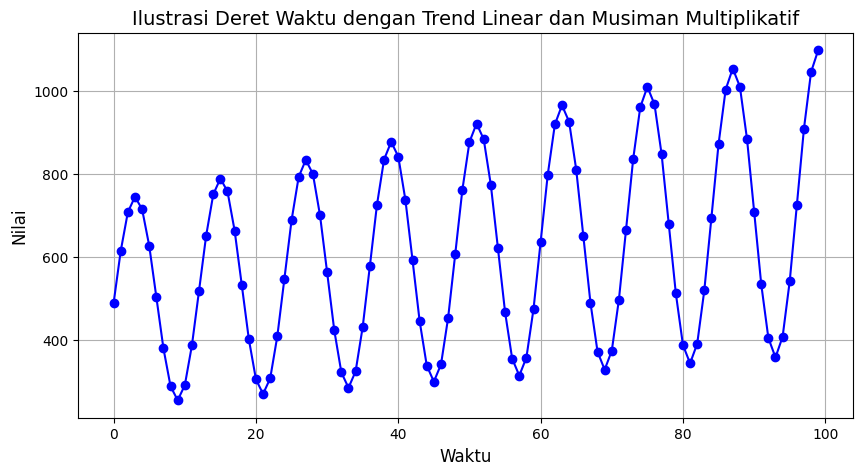

In [238]:
plt.figure(figsize=(10, 5))
plt.plot(x, series_multi, color='b', marker='o')
plt.xlabel('Waktu', fontsize=12)
plt.ylabel('Nilai', fontsize=12)
plt.title('Ilustrasi Deret Waktu dengan Trend Linear dan Musiman Multiplikatif', fontsize=14)
plt.grid()
plt.show()

Dekomposisi dengan model multiplikatif hanya bisa dilakukan untuk deret dengan nilai >0, sehingga jika deret memiliki nilai 0 atau negatif maka deret perlu ditransformasi.

In [239]:
#  Dekomposisi dengan model multiplikatif
# mengubah data menjadi format dataframe
df_multi = pd.DataFrame(series_multi, columns=['Value'])

from statsmodels.tsa.seasonal import seasonal_decompose
result_multi = seasonal_decompose(df_multi['Value'], model='multiplicative', period=12)

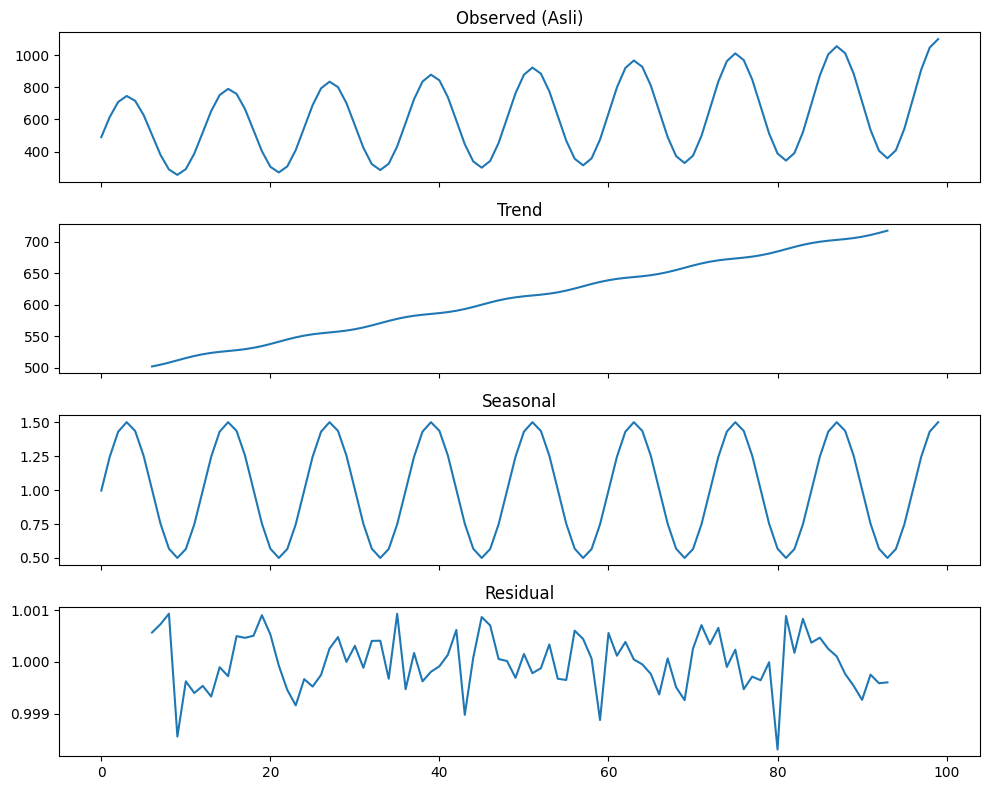

In [240]:
# Plot hasil dekomposisi
fig, axes = plt.subplots(4, 1, figsize=(10, 8), sharex=True)
result_multi.observed.plot(ax=axes[0], title='Observed (Asli)')
result_multi.trend.plot(ax=axes[1], title='Trend')
result_multi.seasonal.plot(ax=axes[2], title='Seasonal')
result_multi.resid.plot(ax=axes[3], title='Residual')

plt.tight_layout()
plt.show()

**Bagaimana Anda menginterpretasikan plot hasil dekomposisi tersebut?**

1. Observed (Asli)

Pada plot data asli terlihat adanya kecenderungan meningkat dari waktu ke waktu, disertai pola naik-turun yang berulang. Selain itu, besar fluktuasi musimannya juga tampak semakin besar ketika level deret semakin tinggi. Pada periode awal, selisih antara puncak dan lembah masih relatif kecil. Namun, semakin besar periode, jarak antara puncak dan lembah semakin lebar.

2. Trend

Komponen trend menunjukkan peningkatan jangka panjang yang konsisten. Nilai trend terus bertambah dari awal hingga akhir periode, meskipun bentuknya tidak benar-benar berupa garis lurus. Dengan demikian, terdapat kecenderungan pertumbuhan nilai deret dari waktu ke waktu.

3. Seasonal

Komponen seasonal menunjukkan pola naik dan turun yang berulang secara teratur setiap 12 periode. Besarnya pola musiman relatif stabil dalam bentuk faktor pengali, sehingga menunjukkan adanya komponen musiman yang konsisten.

4. Residual

Komponen residual mayoritas nilai residual  berada relatif dekat dengan nilai 1 dan berfluktuasi dalam rentang yang cukup kecil. Terdapat sedikit penyimpangan pada beberapa periode, terutama di bagian awal, tetapi setelah itu residual terlihat relatif stabil dan tidak menunjukkan pola naik-turun yang berulang secara teratur. Hal ini menunjukkan bahwa setelah komponen trend dan musiman dipisahkan, tidak banyak pola sistematis yang masih tersisa pada deret.

Kesimpulan:

Hasil dekomposisi multiplikatif menunjukkan bahwa deret memiliki trend yang meningkat serta pola musiman yang berulang setiap 12 periode. Pada data asli, besar fluktuasi terlihat semakin meningkat seiring dengan meningkatnya level deret, sehingga penggunaan model multiplikatif sesuai dengan karakteristik data. Setelah komponen trend dan musiman dipisahkan, residual terlihat relatif stabil dan tidak menunjukkan pola sistematis yang kuat. Dengan demikian, komponen trend dan musiman telah mampu menjelaskan sebagian besar pola pada deret waktu.

In [241]:
# Parameter
np.random.seed(1049)
n = 100  # Jumlah titik data
x = np.arange(n)

# Hanya noise acak tanpa trend atau musiman
noise = np.random.normal(loc=10, scale=2, size=n)  # Nilai acak sekitar 10

# Buat DataFrame untuk regresi
df = pd.DataFrame({'Time': x, 'Series': noise})
df['Time'] = pd.to_datetime(df['Time'], unit='D')  # Konversi ke format waktu
df.set_index('Time', inplace=True)

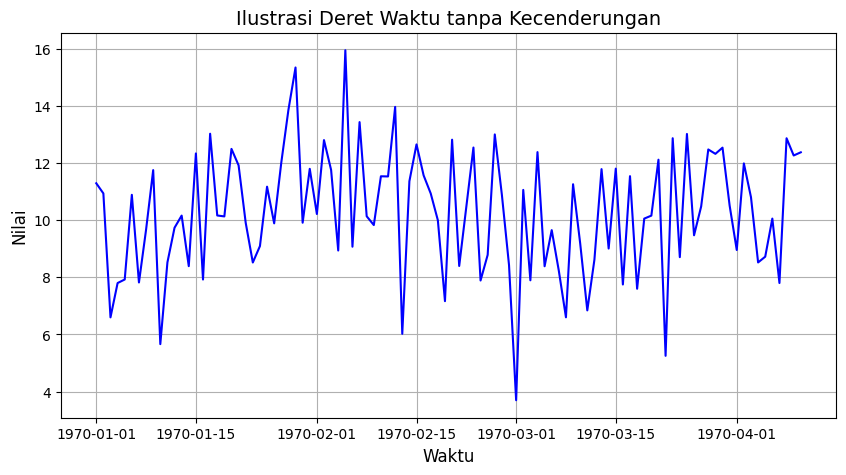

In [242]:
plt.figure(figsize=(10, 5))
plt.plot(df.index, df['Series'], color='b')
plt.xlabel('Waktu', fontsize=12)
plt.ylabel('Nilai', fontsize=12)
plt.title('Ilustrasi Deret Waktu tanpa Kecenderungan', fontsize=14)
plt.grid()
plt.show()

Berdasarkan plot deret waktu, nilai deret berfluktuasi secara acak di sekitar level yang relatif konstan, yaitu sekitar nilai 10. Tidak terlihat adanya pola peningkatan atau penurunan jangka panjang, sehingga deret tidak menunjukkan adanya komponen trend. Selain itu, pola naik-turun yang terjadi juga tidak tampak berulang secara teratur, sehingga tidak terdapat indikasi pola musiman yang jelas. Dengan demikian, deret dapat dikatakan tidak memiliki kecenderungan tertentu dan hanya berfluktuasi di sekitar nilai rata-ratanya.

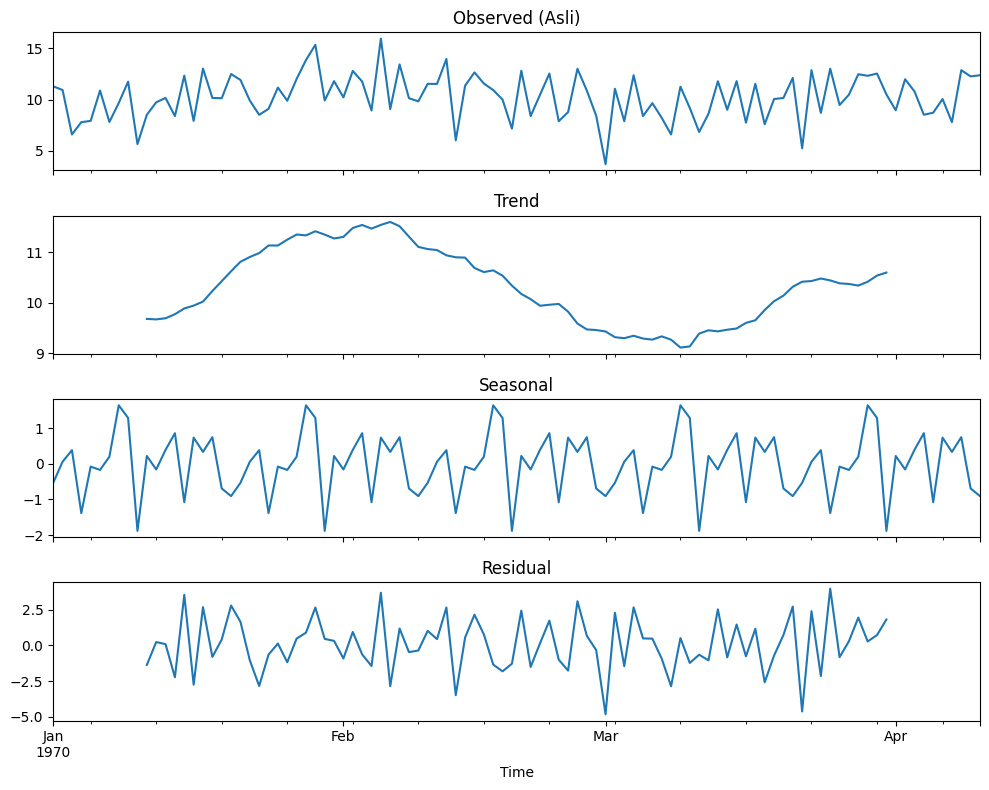

In [243]:
# Lakukan dekomposisi dengan model aditif
result = seasonal_decompose(df['Series'], model='additive', period=20)

# Plot hasil dekomposisi
fig, axes = plt.subplots(4, 1, figsize=(10, 8), sharex=True)
result.observed.plot(ax=axes[0], title='Observed (Asli)')
result.trend.plot(ax=axes[1], title='Trend')
result.seasonal.plot(ax=axes[2], title='Seasonal')
result.resid.plot(ax=axes[3], title='Residual')

plt.tight_layout()
plt.show()

**Bagaimana interpretasi dari plot tersebut?**

1. Observed (Asli)

Pada plot Observed, nilai deret berfluktuasi pada kisaran yang relatif sama sepanjang periode pengamatan. Secara visual, tidak terlihat adanya pola peningkatan atau penurunan yang kuat dan konsisten. Fluktuasi antarperiode cukup besar, sehingga pola trend maupun pola musiman belum terlihat jelas pada plot data asli.

2. Trend

Pada komponen Trend, pola jangka panjang terlihat lebih jelas. Pada awal periode, trend meningkat dari sekitar 9.7 hingga mencapai sekitar 11.5. Setelah mencapai puncak, trend menurun secara bertahap hingga sekitar 9.2, kemudian meningkat lagi pada bagian akhir periode. Hal ini menunjukkan bahwa kecenderungan jangka panjang deret tidak bersifat linear, melainkan mengalami fase peningkatan, kemudian penurunan, lalu kembali meningkat.

3. Seasonal

Pada komponen Seasonal, terlihat pola naik-turun yang berulang dengan bentuk yang mirip. Karena dekomposisi menggunakan period=20, maka pola tersebut menunjukkan adanya komponen musiman yang berulang setiap 20 pengamatan. Nilai seasonal berfluktuasi di sekitar nol, dengan kisaran kurang lebih -2 hingga 2.
Dengan demikian, terdapat pola musiman yang berulang secara teratur setiap 20 periode.

4. Residual

Pada komponen Residual, nilai residual berfluktuasi di sekitar nol tanpa menunjukkan pola naik, turun, maupun pola berulang yang jelas. Terdapat beberapa residual yang cukup ekstrem, khususnya pada bagian tengah dan akhir periode, tetapi kemunculannya tidak membentuk pola tertentu.
Hal ini menunjukkan bahwa setelah komponen trend dan musiman dipisahkan, sisa variasi data relatif bersifat acak. Dengan demikian, tidak terlihat masih adanya struktur pola kuat yang tersisa pada residual.

Kesimpulan:

Berdasarkan hasil dekomposisi aditif, data asli menunjukkan fluktuasi yang cukup besar sehingga pola trend dan musiman belum terlihat jelas secara langsung. Setelah dilakukan dekomposisi, terlihat adanya komponen trend yang meningkat pada awal periode, kemudian menurun, dan kembali meningkat pada akhir periode. Selain itu, terdapat pola musiman yang berulang setiap 20 pengamatan. Residual yang tersisa berfluktuasi secara relatif acak di sekitar nol, sehingga komponen trend dan musiman telah mampu menangkap sebagian besar struktur utama dalam deret waktu.